# 제주 특산물 가격 예측 - 탐색적 데이터 분석 (EDA)

**DACON 대회**: [제주도 특산물 가격 예측 AI 경진대회](https://dacon.io/competitions/official/236176/data)

## 분석 목차
1. 라이브러리 및 데이터 로드
2. 데이터 기본 정보 확인
3. 결측치 분석
4. 타겟 변수 분포 분석
5. 시계열 패턴 분석
6. 품목별 가격 분석
7. 계절성 분석
8. 상관관계 분석
9. 이상치 탐지
10. 특성 중요도 사전 분석
11. 인사이트 요약

## 1. 라이브러리 및 데이터 로드

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 6)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [38]:
# 데이터 로드
# DACON에서 다운로드한 파일을 data/ 폴더에 위치시키세요
import os

DATA_PATH = './data/'

train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'Submission  : {sample_submission.shape}')

Train shape : (59397, 7)
Test  shape : (1092, 5)
Submission  : (1092, 2)


## 2. 데이터 기본 정보 확인

In [39]:
print('=== Train 데이터 상위 5행 ===')
train.head()

=== Train 데이터 상위 5행 ===


,ID,timestamp,item,corporation,location,supply(kg),price(원/kg)
0,TG_A_J_20190101,2019-01-01,TG,A,J,0.0,0.0
1,TG_A_J_20190102,2019-01-02,TG,A,J,0.0,0.0
2,TG_A_J_20190103,2019-01-03,TG,A,J,60601.0,1728.0
3,TG_A_J_20190104,2019-01-04,TG,A,J,25000.0,1408.0
4,TG_A_J_20190105,2019-01-05,TG,A,J,32352.0,1250.0


In [40]:
print('=== Test 데이터 상위 5행 ===')
test.head()

=== Test 데이터 상위 5행 ===


,ID,timestamp,item,corporation,location
0,TG_A_J_20230304,2023-03-04,TG,A,J
1,TG_A_J_20230305,2023-03-05,TG,A,J
2,TG_A_J_20230306,2023-03-06,TG,A,J
3,TG_A_J_20230307,2023-03-07,TG,A,J
4,TG_A_J_20230308,2023-03-08,TG,A,J


In [41]:
print('=== Train 데이터 정보 ===')
train.info()

=== Train 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 59397 entries, 0 to 59396
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           59397 non-null  str    
 1   timestamp    59397 non-null  str    
 2   item         59397 non-null  str    
 3   corporation  59397 non-null  str    
 4   location     59397 non-null  str    
 5   supply(kg)   59397 non-null  float64
 6   price(원/kg)  59397 non-null  float64
dtypes: float64(2), str(5)
memory usage: 3.2 MB


In [42]:
print('=== 컬럼별 데이터 타입 및 고유값 수 ===')
summary = pd.DataFrame({
    'dtype': train.dtypes,
    'nunique': train.nunique(),
    'null_count': train.isnull().sum(),
    'null_pct': (train.isnull().sum() / len(train) * 100).round(2)
})
summary

=== 컬럼별 데이터 타입 및 고유값 수 ===


,dtype,nunique,null_count,null_pct
ID,str,59397,0,0.0
timestamp,str,1523,0,0.0
item,str,5,0,0.0
corporation,str,6,0,0.0
location,str,2,0,0.0
supply(kg),float64,12521,0,0.0
price(원/kg),float64,7094,0,0.0


In [43]:
print('=== 수치형 변수 기초 통계 ===')
train.describe()

=== 수치형 변수 기초 통계 ===


,supply(kg),price(원/kg)
count,5.939700e+04,59397.000000
mean,1.189453e+04,1131.680674
std,5.226400e+04,2029.941445
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,3.800000e+03,1519.000000
max,1.222800e+06,20909.000000


In [44]:
# 날짜 컬럼 파악 및 변환 (실제 컬럼명에 맞게 수정하세요)
# 일반적으로 '시점', 'date', '날짜' 등의 컬럼명 사용
date_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['시점', 'date', '날짜', 'time', '년월', '연도']):
        date_col = col
        break

if date_col:
    print(f'날짜 컬럼 발견: {date_col}')
    train[date_col] = pd.to_datetime(train[date_col])
    test[date_col]  = pd.to_datetime(test[date_col])
    print(f'Train 기간: {train[date_col].min()} ~ {train[date_col].max()}')
    print(f'Test  기간: {test[date_col].min()} ~ {test[date_col].max()}')
else:
    print('날짜 컬럼을 자동으로 찾지 못했습니다. 컬럼명을 확인하세요.')
    print('Train 컬럼:', list(train.columns))

날짜 컬럼 발견: timestamp
Train 기간: 2019-01-01 00:00:00 ~ 2023-03-03 00:00:00
Test  기간: 2023-03-04 00:00:00 ~ 2023-03-31 00:00:00


In [45]:
# 품목 컬럼 파악
item_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['품목', '품종', '작물', 'item', 'product', '상품']):
        item_col = col
        break

if item_col:
    print(f'품목 컬럼: {item_col}')
    print(f'품목 종류: {train[item_col].unique()}')
    print(f'품목별 데이터 수:')
    print(train[item_col].value_counts())
else:
    print('품목 컬럼을 자동으로 찾지 못했습니다.')
    print('Train 컬럼:', list(train.columns))

품목 컬럼: item
품목 종류: <StringArray>
['TG', 'CR', 'CB', 'RD', 'BC']
Length: 5, dtype: str
품목별 데이터 수:
item
TG    15230
BC    13707
RD    12184
CR    10661
CB     7615
Name: count, dtype: int64


In [46]:
# 타겟 컬럼 파악
target_col = None
for col in train.columns:
    if any(keyword in col for keyword in ['가격', 'price', '평균가', '단가']):
        target_col = col
        break

print(f'타겟 컬럼(추정): {target_col}')
if target_col:
    print(train[target_col].describe())

타겟 컬럼(추정): price(원/kg)
count    59397.000000
mean      1131.680674
std       2029.941445
min          0.000000
25%          0.000000
50%          0.000000
75%       1519.000000
max      20909.000000
Name: price(원/kg), dtype: float64


## 3. 결측치 분석

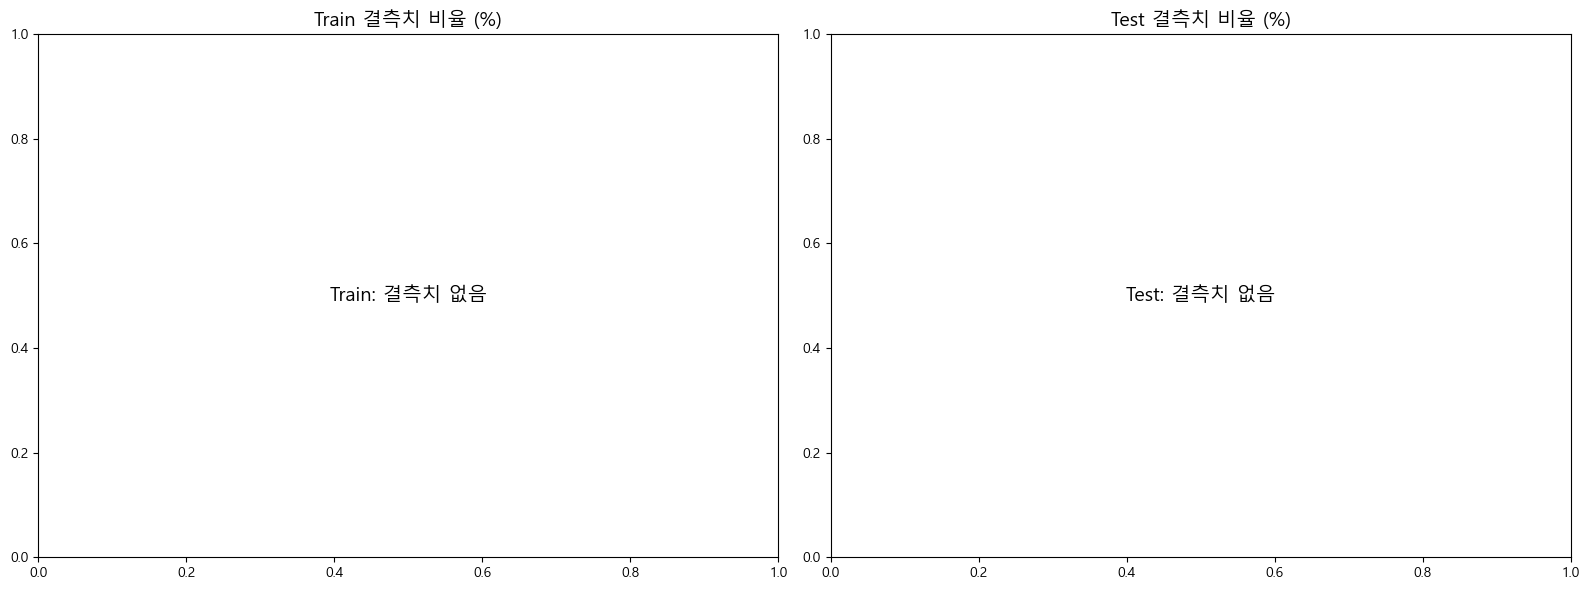

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train 결측치
missing_train = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]

if len(missing_train) > 0:
    missing_train.plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Train 결측치 비율 (%)', fontsize=14)
    axes[0].set_ylabel('결측치 비율 (%)')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'Train: 결측치 없음', ha='center', va='center', fontsize=14)
    axes[0].set_title('Train 결측치 비율 (%)', fontsize=14)

# Test 결측치
missing_test = (test.isnull().sum() / len(test) * 100).sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]

if len(missing_test) > 0:
    missing_test.plot(kind='bar', ax=axes[1], color='steelblue')
    axes[1].set_title('Test 결측치 비율 (%)', fontsize=14)
    axes[1].set_ylabel('결측치 비율 (%)')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'Test: 결측치 없음', ha='center', va='center', fontsize=14)
    axes[1].set_title('Test 결측치 비율 (%)', fontsize=14)

plt.tight_layout()
plt.show()

In [48]:
# 결측치 히트맵
if train.isnull().sum().sum() > 0:
    plt.figure(figsize=(14, 6))
    sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Train 결측치 패턴', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Train 데이터에 결측치가 없습니다.')

Train 데이터에 결측치가 없습니다.


### 3-1. 위장 결측치 검증 (문자열·특수값 형태의 결측치 탐지)

`isnull()`로는 잡히지 않지만 실질적으로 결측치 역할을 하는 값들을 다방면으로 점검합니다.

| 검증 항목 | 대상 패턴 |
|---|---|
| ① 문자열 결측 표현 | "없음", "N/A", "-", "null", "모름", "해당없음" 등 |
| ② 공백·빈 문자열 | `""`, `"  "` (whitespace only) |
| ③ 수치형 위장 결측 | `-999`, `-1`, `0`, `9999`, `999999` 등 placeholder |
| ④ 카테고리 고유값 전수 확인 | 범주형 컬럼의 unique 값 목록 직접 확인 |
| ⑤ 종합 히트맵 | 위 항목 통합 시각화 |

In [49]:
# ① 문자열 결측 표현 탐지
# 자주 쓰이는 결측 표현 패턴 정의
STRING_MISSING_PATTERNS = [
    '없음', '모름', '해당없음', '해당 없음', '정보없음', '미상', '기타',
    'N/A', 'n/a', 'NA', 'na', 'NaN', 'nan', 'null', 'NULL', 'Null',
    'none', 'None', 'NONE', '-', '--', '---', '.', '?', '??', 'X', 'x',
    '0', '', ' ', '미기재', '미입력', '알수없음', '알 수 없음', 'unknown', 'Unknown'
]

print('=' * 65)
print('① 문자열 결측 표현 탐지 (isnull()에 잡히지 않는 값)')
print('=' * 65)

obj_cols = train.select_dtypes(include='object').columns.tolist()
found_any = False

str_missing_report = {}

for col in obj_cols:
    col_series = train[col].astype(str).str.strip()
    matched = {}
    for pat in STRING_MISSING_PATTERNS:
        mask = col_series == pat.strip()
        cnt = mask.sum()
        if cnt > 0:
            matched[pat if pat.strip() != '' else '(빈 문자열)'] = cnt
    if matched:
        found_any = True
        str_missing_report[col] = matched
        print(f'\n  [컬럼: {col}]')
        for pat, cnt in sorted(matched.items(), key=lambda x: -x[1]):
            pct = cnt / len(train) * 100
            print(f'    {repr(pat):20s} → {cnt:5,}개 ({pct:.2f}%)')

# Test 데이터도 동일하게 검사
print('\n--- Test 데이터 ---')
str_missing_report_test = {}
obj_cols_test = test.select_dtypes(include='object').columns.tolist()
found_any_test = False

for col in obj_cols_test:
    col_series = test[col].astype(str).str.strip()
    matched = {}
    for pat in STRING_MISSING_PATTERNS:
        mask = col_series == pat.strip()
        cnt = mask.sum()
        if cnt > 0:
            matched[pat if pat.strip() != '' else '(빈 문자열)'] = cnt
    if matched:
        found_any_test = True
        str_missing_report_test[col] = matched
        print(f'\n  [컬럼: {col}]')
        for pat, cnt in sorted(matched.items(), key=lambda x: -x[1]):
            pct = cnt / len(test) * 100
            print(f'    {repr(pat):20s} → {cnt:5,}개 ({pct:.2f}%)')

if not found_any:
    print('  Train: 문자열 결측 표현 없음')
if not found_any_test:
    print('  Test : 문자열 결측 표현 없음')

① 문자열 결측 표현 탐지 (isnull()에 잡히지 않는 값)

--- Test 데이터 ---
  Train: 문자열 결측 표현 없음
  Test : 문자열 결측 표현 없음


In [50]:
# ② 공백·빈 문자열 상세 탐지 (정규식 기반)
import re

print('=' * 65)
print('② 공백·빈 문자열 탐지 (strip 후 길이 0인 값)')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    print(f'\n  [{df_name}]')
    obj_cols_chk = df.select_dtypes(include='object').columns
    found = False
    for col in obj_cols_chk:
        # 실제 NaN은 제외하고 문자열만 검사
        str_vals = df[col].dropna().astype(str)
        empty_mask = str_vals.str.strip() == ''
        cnt_empty = empty_mask.sum()

        whitespace_only = str_vals.str.fullmatch(r'\s+')
        cnt_ws = whitespace_only.sum() if whitespace_only is not None else 0

        if cnt_empty > 0 or cnt_ws > 0:
            found = True
            print(f'    {col}: 빈 문자열 {cnt_empty}개 / 공백만 있는 값 {cnt_ws}개')
    if not found:
        print('    해당 없음')

② 공백·빈 문자열 탐지 (strip 후 길이 0인 값)

  [Train]
    해당 없음

  [Test]
    해당 없음


In [51]:
# ③ 수치형 컬럼의 placeholder 결측치 탐지
# 도메인에서 불가능한 극단값이 데이터 입력 오류나 결측 대체값일 가능성 검사
NUMERIC_MISSING_SUSPECTS = [-999, -9999, -99999, -1, 999, 9999, 99999, 999999, 0]

print('=' * 65)
print('③ 수치형 컬럼 Placeholder 결측치 탐지')
print('   (도메인상 불가능한 sentinel 값 의심)')
print('=' * 65)

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

for df_name, df in [('Train', train), ('Test', test)]:
    print(f'\n  [{df_name}]')
    found = False
    for col in num_cols:
        if col not in df.columns:
            continue
        series = df[col].dropna()
        suspects = {}
        for val in NUMERIC_MISSING_SUSPECTS:
            cnt = (series == val).sum()
            if cnt > 0:
                pct = cnt / len(df) * 100
                suspects[val] = (cnt, pct)
        if suspects:
            found = True
            print(f'\n    [컬럼: {col}]  (min={series.min():.1f}, max={series.max():.1f})')
            for val, (cnt, pct) in sorted(suspects.items(), key=lambda x: -x[1][0]):
                print(f'      값 {val:>8} → {cnt:5,}개 ({pct:.2f}%)')
    if not found:
        print('    의심 값 없음')

print('\n  ※ 위 값들이 실제 측정값인지 결측 대체값인지 도메인 지식으로 판단하세요.')

③ 수치형 컬럼 Placeholder 결측치 탐지
   (도메인상 불가능한 sentinel 값 의심)

  [Train]

    [컬럼: supply(kg)]  (min=0.0, max=1222800.0)
      값        0 → 35,452개 (59.69%)
      값      999 →     1개 (0.00%)

    [컬럼: price(원/kg)]  (min=0.0, max=20909.0)
      값        0 → 35,455개 (59.69%)
      값      999 →     7개 (0.01%)

  [Test]
    의심 값 없음

  ※ 위 값들이 실제 측정값인지 결측 대체값인지 도메인 지식으로 판단하세요.


In [52]:
# ④ 범주형 컬럼 고유값 전수 확인
# 눈으로 직접 살펴봐야 잡히는 위장 결측치 확인
print('=' * 65)
print('④ 범주형(object) 컬럼 고유값 전수 확인 (Train)')
print('=' * 65)

obj_cols_all = train.select_dtypes(include='object').columns.tolist()

for col in obj_cols_all:
    uniq_vals = train[col].unique()
    n_uniq = len(uniq_vals)
    print(f'\n  [컬럼: {col}]  고유값 {n_uniq}개')
    if n_uniq <= 50:
        # 값, 빈도, 비율 테이블로 출력
        vc = train[col].value_counts(dropna=False)
        for val, cnt in vc.items():
            pct = cnt / len(train) * 100
            flag = ' ★의심' if str(val).strip() in [p.strip() for p in STRING_MISSING_PATTERNS] else ''
            print(f'    {repr(val):30s}  {cnt:6,}개  ({pct:5.1f}%){flag}')
    else:
        # 고유값이 너무 많으면 상위/하위 5개만 표시
        print(f'    (고유값이 {n_uniq}개로 많아 상위 5 / 하위 5만 표시)')
        vc = train[col].value_counts(dropna=False)
        for val, cnt in vc.head(5).items():
            print(f'    TOP  {repr(val):30s}  {cnt:6,}개')
        for val, cnt in vc.tail(5).items():
            print(f'    TAIL {repr(val):30s}  {cnt:6,}개')

④ 범주형(object) 컬럼 고유값 전수 확인 (Train)

  [컬럼: ID]  고유값 59397개
    (고유값이 59397개로 많아 상위 5 / 하위 5만 표시)
    TOP  'TG_A_J_20190101'                    1개
    TOP  'TG_A_J_20190102'                    1개
    TOP  'TG_A_J_20190103'                    1개
    TOP  'TG_A_J_20190104'                    1개
    TOP  'TG_A_J_20190105'                    1개
    TAIL 'RD_F_J_20230227'                    1개
    TAIL 'RD_F_J_20230228'                    1개
    TAIL 'RD_F_J_20230301'                    1개
    TAIL 'RD_F_J_20230302'                    1개
    TAIL 'RD_F_J_20230303'                    1개

  [컬럼: item]  고유값 5개
    'TG'                            15,230개  ( 25.6%)
    'BC'                            13,707개  ( 23.1%)
    'RD'                            12,184개  ( 20.5%)
    'CR'                            10,661개  ( 17.9%)
    'CB'                             7,615개  ( 12.8%)

  [컬럼: corporation]  고유값 6개
    'A'                             13,707개  ( 23.1%)
    'E'                             13

⑤ 위장 결측치 종합 요약 (Train / Test)

  [Train] — 총 59,397행
    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓

  [Test] — 총 1,092행
    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓


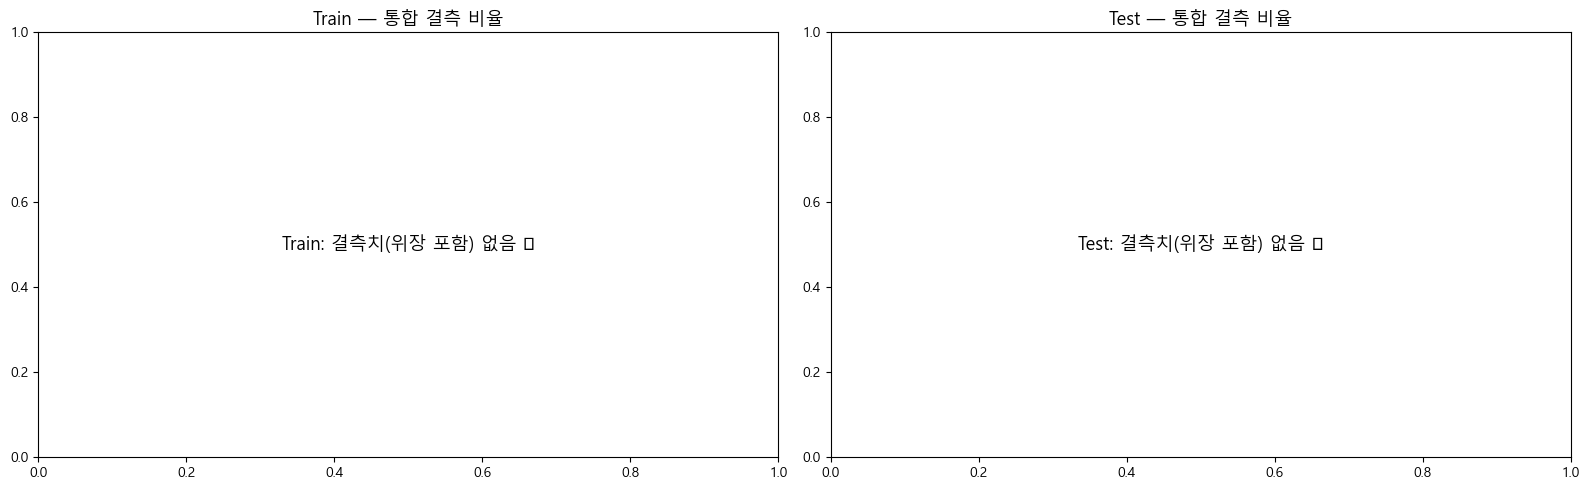

In [53]:
# ⑤ 위장 결측치 종합 히트맵 시각화
# isnull() + 문자열 결측 패턴을 합산한 실질적 결측 현황

def count_hidden_missing(df):
    """isnull + 문자열 위장 결측 패턴을 합산한 컬럼별 결측 수 반환"""
    base_null = df.isnull().sum()
    hidden = pd.Series(0, index=df.columns)

    for col in df.select_dtypes(include='object').columns:
        stripped = df[col].dropna().astype(str).str.strip()
        for pat in STRING_MISSING_PATTERNS:
            hidden[col] += (stripped == pat.strip()).sum()
    return base_null, hidden, base_null + hidden

print('=' * 65)
print('⑤ 위장 결측치 종합 요약 (Train / Test)')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    base, hidden, total = count_hidden_missing(df)
    n = len(df)
    summary_df = pd.DataFrame({
        'isnull() 결측': base,
        '문자열 위장 결측': hidden,
        '합계': total,
        '합계 비율(%)': (total / n * 100).round(2)
    })
    print(f'\n  [{df_name}] — 총 {n:,}행')
    # 합계 > 0인 컬럼만 출력
    display_df = summary_df[summary_df['합계'] > 0]
    if len(display_df) == 0:
        print('    → 모든 컬럼에서 결측치(위장 포함) 없음 ✓')
    else:
        print(display_df.to_string())

# 시각화: 통합 결측 비율 bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df_name, df) in zip(axes, [('Train', train), ('Test', test)]):
    base, hidden, total = count_hidden_missing(df)
    pct_base   = base   / len(df) * 100
    pct_hidden = hidden / len(df) * 100

    cols_show = total[total > 0].index.tolist()
    if not cols_show:
        ax.text(0.5, 0.5, f'{df_name}: 결측치(위장 포함) 없음 ✓',
                ha='center', va='center', fontsize=13)
        ax.set_title(f'{df_name} — 통합 결측 비율', fontsize=13)
        continue

    x = range(len(cols_show))
    ax.bar(x, pct_base[cols_show],   label='isnull() 결측',     color='steelblue', alpha=0.85)
    ax.bar(x, pct_hidden[cols_show], bottom=pct_base[cols_show],
           label='문자열 위장 결측', color='coral',     alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cols_show, rotation=45, ha='right')
    ax.set_ylabel('결측 비율 (%)')
    ax.set_title(f'{df_name} — 통합 결측 비율 (isnull + 위장)', fontsize=13)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# ⑥ 결측치 검증 전체 결과 카운트 요약
# 앞선 ①~⑤ 검증 결과를 한 곳에 모아 총 몇 건의 위장 결측치가 발견됐는지 집계

print('=' * 65)
print('⑥ 결측치 검증 전체 결과 카운트 요약')
print('=' * 65)

for df_name, df in [('Train', train), ('Test', test)]:
    n_rows = len(df)
    print(f'\n▶ [{df_name}]  총 {n_rows:,}행 × {len(df.columns)}열')
    print('-' * 50)

    # --- [A] isnull() 기본 결측치 ---
    null_per_col = df.isnull().sum()
    total_null_cells = null_per_col.sum()           # 전체 결측 셀 수
    null_cols = (null_per_col > 0).sum()             # 결측이 있는 컬럼 수
    print(f'  [A] isnull() 기본 결측치')
    print(f'      결측 셀 수     : {total_null_cells:>8,} 개')
    print(f'      결측 컬럼 수   : {null_cols:>8,} 개')

    # --- [B] 문자열 결측 표현 (① 검증) ---
    hidden_per_col = pd.Series(0, index=df.columns)
    hidden_detail  = {}   # {col: {패턴: 개수}} 형태로 저장

    for col in df.select_dtypes(include='object').columns:
        stripped = df[col].dropna().astype(str).str.strip()
        col_cnt = 0
        col_detail = {}
        for pat in STRING_MISSING_PATTERNS:
            cnt = (stripped == pat.strip()).sum()
            if cnt > 0:
                col_detail[pat if pat.strip() != '' else '(빈문자열)'] = cnt
                col_cnt += cnt
        hidden_per_col[col] = col_cnt
        if col_cnt > 0:
            hidden_detail[col] = col_detail

    total_hidden_cells = hidden_per_col.sum()        # 전체 위장 결측 셀 수
    hidden_cols        = (hidden_per_col > 0).sum()  # 위장 결측이 있는 컬럼 수
    total_hidden_patterns = sum(                     # 발견된 패턴 종류 수
        len(v) for v in hidden_detail.values()
    )
    print(f'\n  [B] 문자열 위장 결측 (없음·N/A·- 등)')
    print(f'      위장 결측 셀 수     : {total_hidden_cells:>8,} 개')
    print(f'      위장 결측 컬럼 수   : {hidden_cols:>8,} 개')
    print(f'      발견된 패턴 종류 수 : {total_hidden_patterns:>8,} 가지')

    # 컬럼별 세부 내역 출력
    if hidden_detail:
        print('      ┌ 컬럼별 세부 내역')
        for col, detail in hidden_detail.items():
            col_total = sum(detail.values())
            patterns_str = ', '.join(f'{repr(p)}={c}개' for p, c in detail.items())
            print(f'      │  {col}: 합계 {col_total}개  ({patterns_str})')
        print('      └─')

    # --- [C] 공백·빈 문자열 (② 검증) ---
    total_empty = 0
    total_ws    = 0
    for col in df.select_dtypes(include='object').columns:
        str_vals = df[col].dropna().astype(str)
        total_empty += (str_vals.str.strip() == '').sum()
        total_ws    += str_vals.str.fullmatch(r'\s+').sum()

    print(f'\n  [C] 공백·빈 문자열')
    print(f'      빈 문자열("") 셀 수 : {total_empty:>8,} 개')
    print(f'      공백만 있는 셀 수   : {total_ws:>8,} 개')

    # --- [D] 수치형 Placeholder (③ 검증) ---
    placeholder_total = 0
    placeholder_detail = {}   # {col: {값: 개수}}

    for col in df.select_dtypes(include=[np.number]).columns:
        series = df[col].dropna()
        col_cnt = 0
        col_detail = {}
        for val in NUMERIC_MISSING_SUSPECTS:
            cnt = (series == val).sum()
            if cnt > 0:
                col_detail[val] = cnt
                col_cnt += cnt
        if col_cnt > 0:
            placeholder_detail[col] = col_detail
            placeholder_total += col_cnt

    placeholder_cols = len(placeholder_detail)       # 의심 컬럼 수
    print(f'\n  [D] 수치형 Placeholder 의심값 (-999, 0, 9999 등)')
    print(f'      의심 셀 수     : {placeholder_total:>8,} 개')
    print(f'      의심 컬럼 수   : {placeholder_cols:>8,} 개')

    if placeholder_detail:
        print('      ┌ 컬럼별 세부 내역')
        for col, detail in placeholder_detail.items():
            col_total = sum(detail.values())
            details_str = ', '.join(f'{v}={c}개' for v, c in detail.items())
            print(f'      │  {col}: 합계 {col_total}개  ({details_str})')
        print('      └─')

    # --- 최종 합산 ---
    grand_total = total_null_cells + total_hidden_cells + total_empty + total_ws
    print(f'\n  {"─"*48}')
    print(f'  ★ 최종 합산 (A + B + C)')
    print(f'      전체 의심 결측 셀 수  : {grand_total:>8,} 개')
    print(f'      전체 행 대비 비율     : {grand_total / (n_rows * len(df.columns)) * 100:>8.3f} %')
    if grand_total == 0:
        print('      → 위장 결측치 포함 결측치 없음 ✓')
    else:
        print('      → 위의 항목들을 검토하여 전처리 여부를 결정하세요.')

print('\n' + '=' * 65)

⑥ 결측치 검증 전체 결과 카운트 요약

▶ [Train]  총 59,397행 × 7열
--------------------------------------------------
  [A] isnull() 기본 결측치
      결측 셀 수     :        0 개
      결측 컬럼 수   :        0 개

  [B] 문자열 위장 결측 (없음·N/A·- 등)
      위장 결측 셀 수     :        0 개
      위장 결측 컬럼 수   :        0 개
      발견된 패턴 종류 수 :        0 가지

  [C] 공백·빈 문자열
      빈 문자열("") 셀 수 :        0 개
      공백만 있는 셀 수   :        0 개

  [D] 수치형 Placeholder 의심값 (-999, 0, 9999 등)
      의심 셀 수     :   70,915 개
      의심 컬럼 수   :        2 개
      ┌ 컬럼별 세부 내역
      │  supply(kg): 합계 35453개  (999=1개, 0=35452개)
      │  price(원/kg): 합계 35462개  (999=7개, 0=35455개)
      └─

  ────────────────────────────────────────────────
  ★ 최종 합산 (A + B + C)
      전체 의심 결측 셀 수  :        0 개
      전체 행 대비 비율     :    0.000 %
      → 위장 결측치 포함 결측치 없음 ✓

▶ [Test]  총 1,092행 × 5열
--------------------------------------------------
  [A] isnull() 기본 결측치
      결측 셀 수     :        0 개
      결측 컬럼 수   :        0 개

  [B] 문자열 위장 결측 (없음·N/A·- 등)
      위장 결측 셀 수     : 

## 4. 타겟 변수 분포 분석

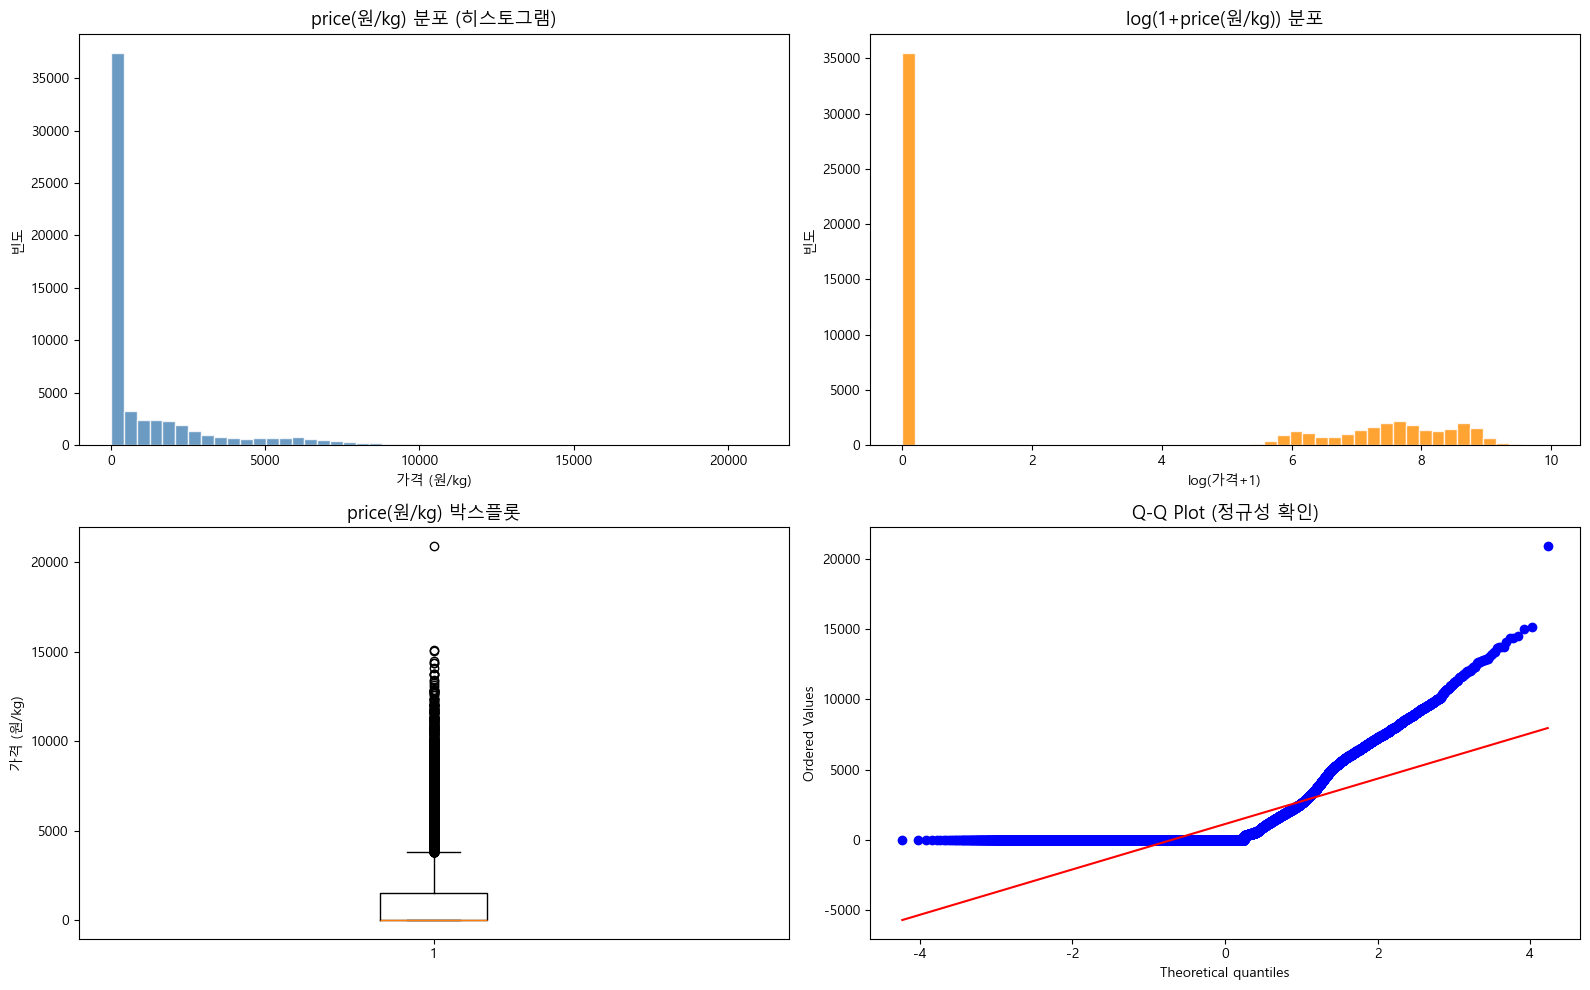

왜도(Skewness): 2.1855
첨도(Kurtosis): 4.6874
log 변환 후 왜도: 0.4707


In [55]:
if target_col:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 히스토그램
    axes[0, 0].hist(train[target_col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, 0].set_title(f'{target_col} 분포 (히스토그램)', fontsize=13)
    axes[0, 0].set_xlabel('가격 (원/kg)')
    axes[0, 0].set_ylabel('빈도')

    # 로그 변환 히스토그램
    log_price = np.log1p(train[target_col].dropna())
    axes[0, 1].hist(log_price, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
    axes[0, 1].set_title(f'log(1+{target_col}) 분포', fontsize=13)
    axes[0, 1].set_xlabel('log(가격+1)')
    axes[0, 1].set_ylabel('빈도')

    # 박스플롯
    axes[1, 0].boxplot(train[target_col].dropna(), vert=True)
    axes[1, 0].set_title(f'{target_col} 박스플롯', fontsize=13)
    axes[1, 0].set_ylabel('가격 (원/kg)')

    # Q-Q 플롯
    stats.probplot(train[target_col].dropna(), dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (정규성 확인)', fontsize=13)

    plt.tight_layout()
    plt.show()

    # 왜도/첨도
    print(f'왜도(Skewness): {train[target_col].skew():.4f}')
    print(f'첨도(Kurtosis): {train[target_col].kurt():.4f}')
    print(f'log 변환 후 왜도: {log_price.skew():.4f}')

## 5. 시계열 패턴 분석

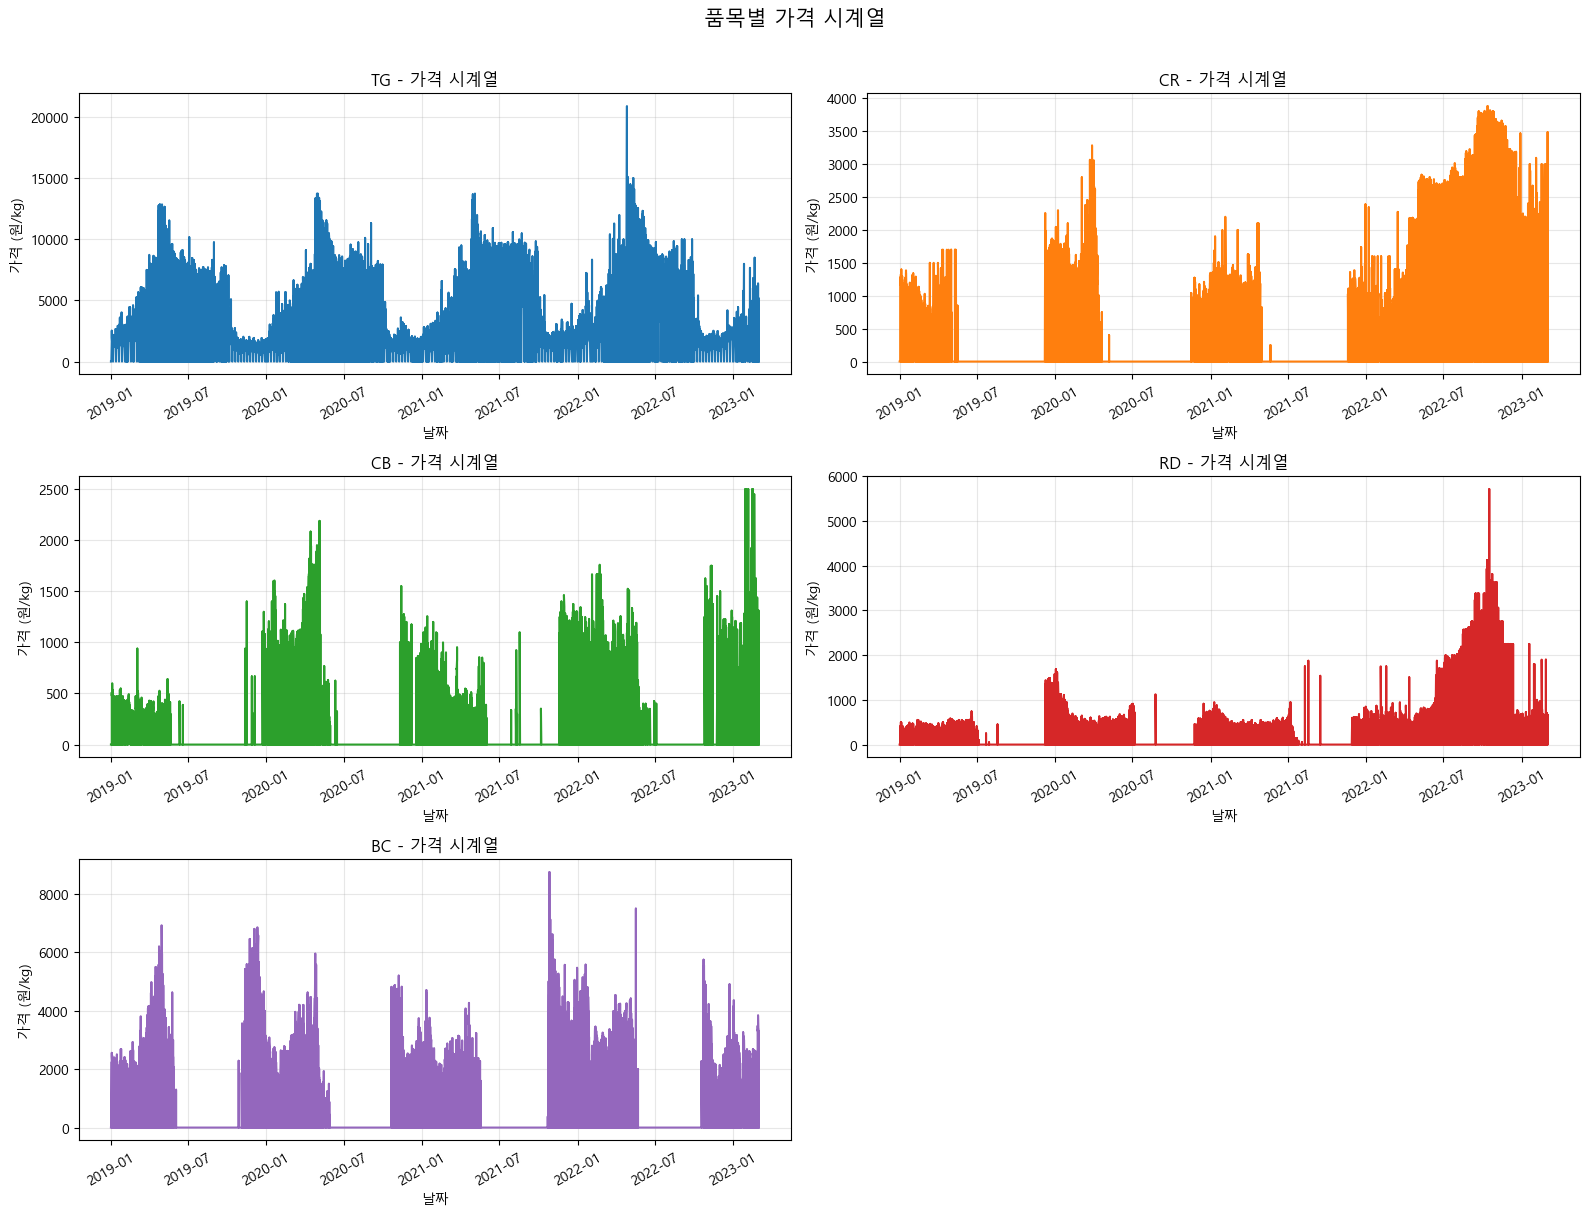

In [56]:
if date_col and target_col:
    # 전체 시계열 추이
    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

        for i, item in enumerate(items):
            df_item = train[train[item_col] == item].sort_values(date_col)
            axes[i].plot(df_item[date_col], df_item[target_col], linewidth=1.5, color=f'C{i}')
            axes[i].set_title(f'{item} - 가격 시계열', fontsize=12)
            axes[i].set_xlabel('날짜')
            axes[i].set_ylabel('가격 (원/kg)')
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=30)

        # 남은 axes 숨기기
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('품목별 가격 시계열', fontsize=15, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        df_sorted = train.sort_values(date_col)
        plt.figure(figsize=(16, 5))
        plt.plot(df_sorted[date_col], df_sorted[target_col], linewidth=1)
        plt.title('전체 가격 시계열', fontsize=14)
        plt.xlabel('날짜')
        plt.ylabel('가격 (원/kg)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

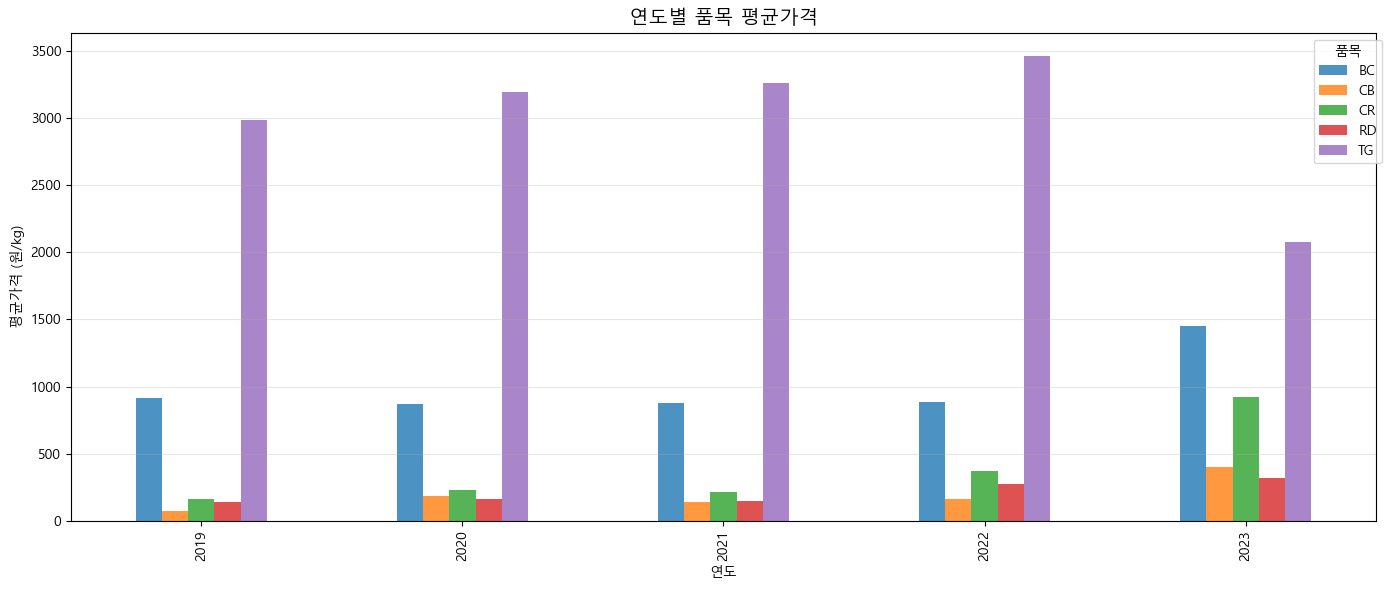

In [57]:
# 연도별 추이 분석
if date_col and target_col:
    train['year']  = train[date_col].dt.year
    train['month'] = train[date_col].dt.month
    train['week']  = train[date_col].dt.isocalendar().week.astype(int)
    train['quarter'] = train[date_col].dt.quarter
    train['dayofweek'] = train[date_col].dt.dayofweek

    if item_col:
        yearly_price = train.groupby(['year', item_col])[target_col].mean().reset_index()
        pivot = yearly_price.pivot(index='year', columns=item_col, values=target_col)
        pivot.plot(kind='bar', figsize=(14, 6), alpha=0.8)
        plt.title('연도별 품목 평균가격', fontsize=14)
        plt.xlabel('연도')
        plt.ylabel('평균가격 (원/kg)')
        plt.legend(title='품목', bbox_to_anchor=(1.01, 1))
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        yearly_price = train.groupby('year')[target_col].mean()
        yearly_price.plot(kind='bar', figsize=(12, 5), color='steelblue', alpha=0.8)
        plt.title('연도별 평균가격', fontsize=14)
        plt.xlabel('연도')
        plt.ylabel('평균가격 (원/kg)')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 6. 품목별 가격 분석

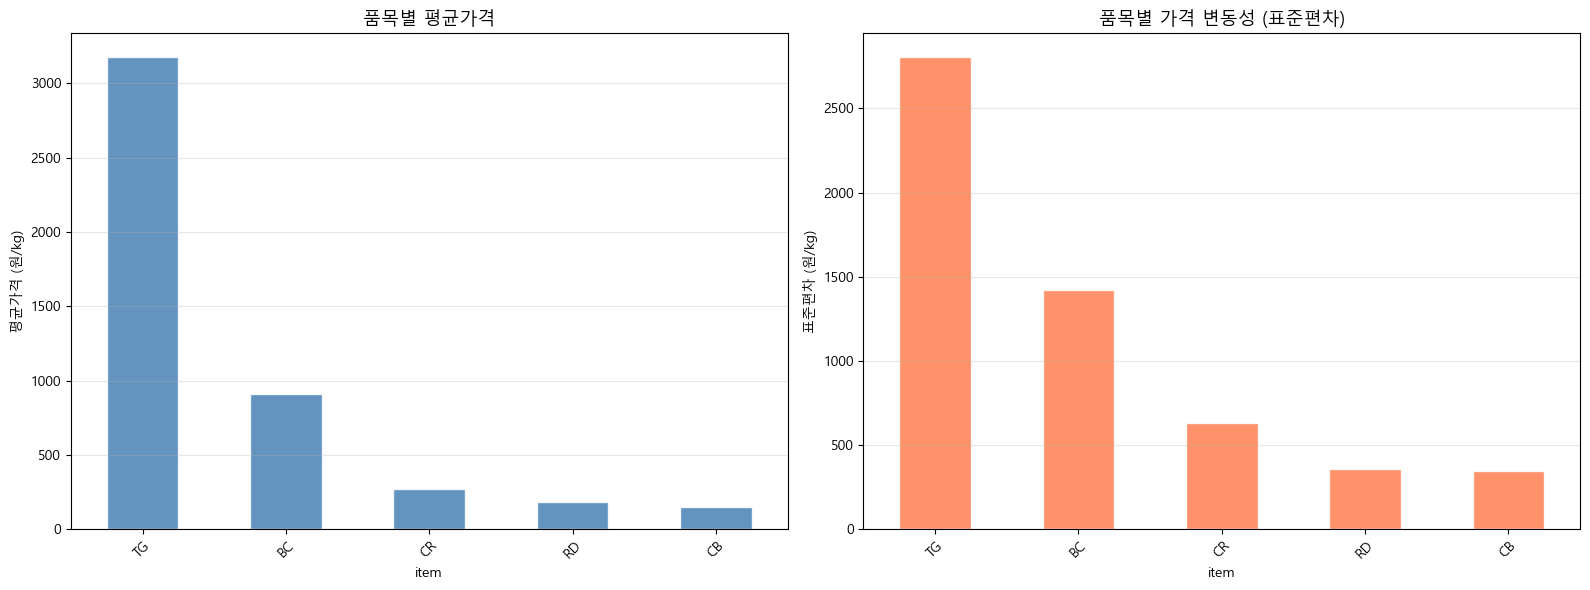

In [58]:
if item_col and target_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 품목별 평균가격 바차트
    item_price_mean = train.groupby(item_col)[target_col].mean().sort_values(ascending=False)
    item_price_mean.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85, edgecolor='white')
    axes[0].set_title('품목별 평균가격', fontsize=13)
    axes[0].set_ylabel('평균가격 (원/kg)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)

    # 품목별 가격 변동성 (표준편차)
    item_price_std = train.groupby(item_col)[target_col].std().sort_values(ascending=False)
    item_price_std.plot(kind='bar', ax=axes[1], color='coral', alpha=0.85, edgecolor='white')
    axes[1].set_title('품목별 가격 변동성 (표준편차)', fontsize=13)
    axes[1].set_ylabel('표준편차 (원/kg)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

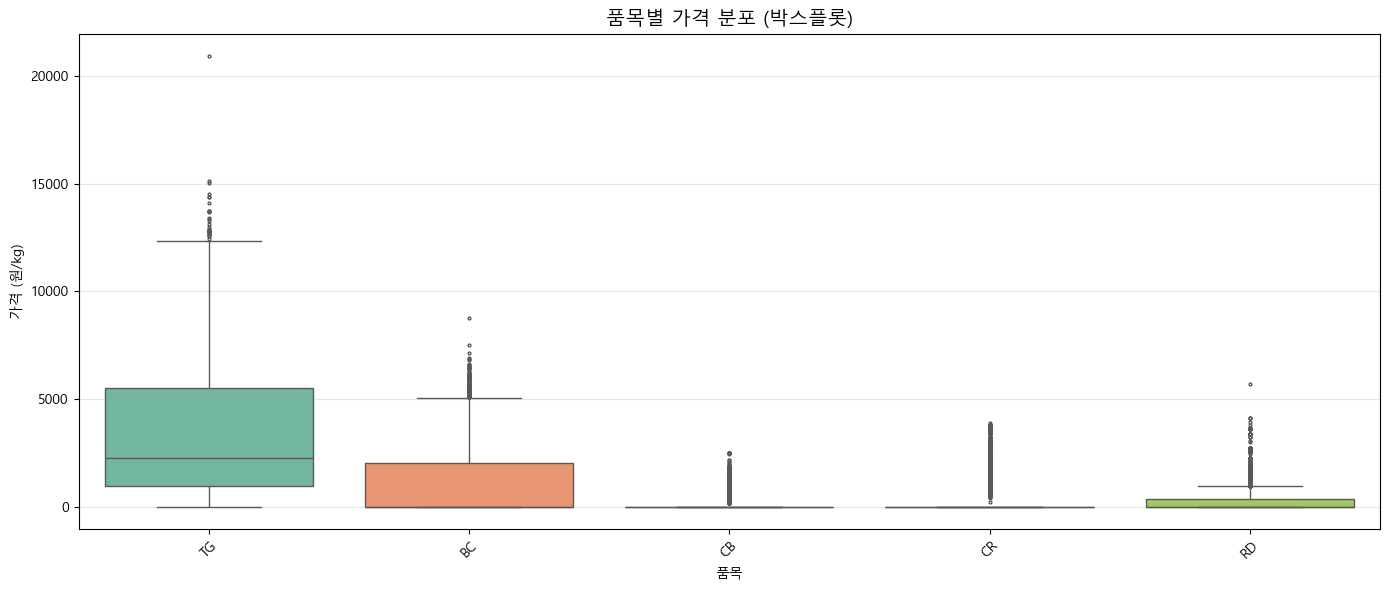

In [59]:
if item_col and target_col:
    # 품목별 박스플롯
    plt.figure(figsize=(14, 6))
    items_order = train.groupby(item_col)[target_col].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=item_col, y=target_col, order=items_order,
                palette='Set2', fliersize=2)
    plt.title('품목별 가격 분포 (박스플롯)', fontsize=14)
    plt.xlabel('품목')
    plt.ylabel('가격 (원/kg)')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [60]:
if item_col and target_col:
    # 품목별 가격 통계 요약
    item_stats = train.groupby(item_col)[target_col].agg(
        ['mean', 'median', 'std', 'min', 'max',
         lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
    ).round(1)
    item_stats.columns = ['평균', '중앙값', '표준편차', '최솟값', '최댓값', 'Q1(25%)', 'Q3(75%)']
    item_stats['변동계수(CV)'] = (item_stats['표준편차'] / item_stats['평균'] * 100).round(1)
    print('=== 품목별 가격 통계 ===')
    item_stats

=== 품목별 가격 통계 ===


## 7. 계절성 분석

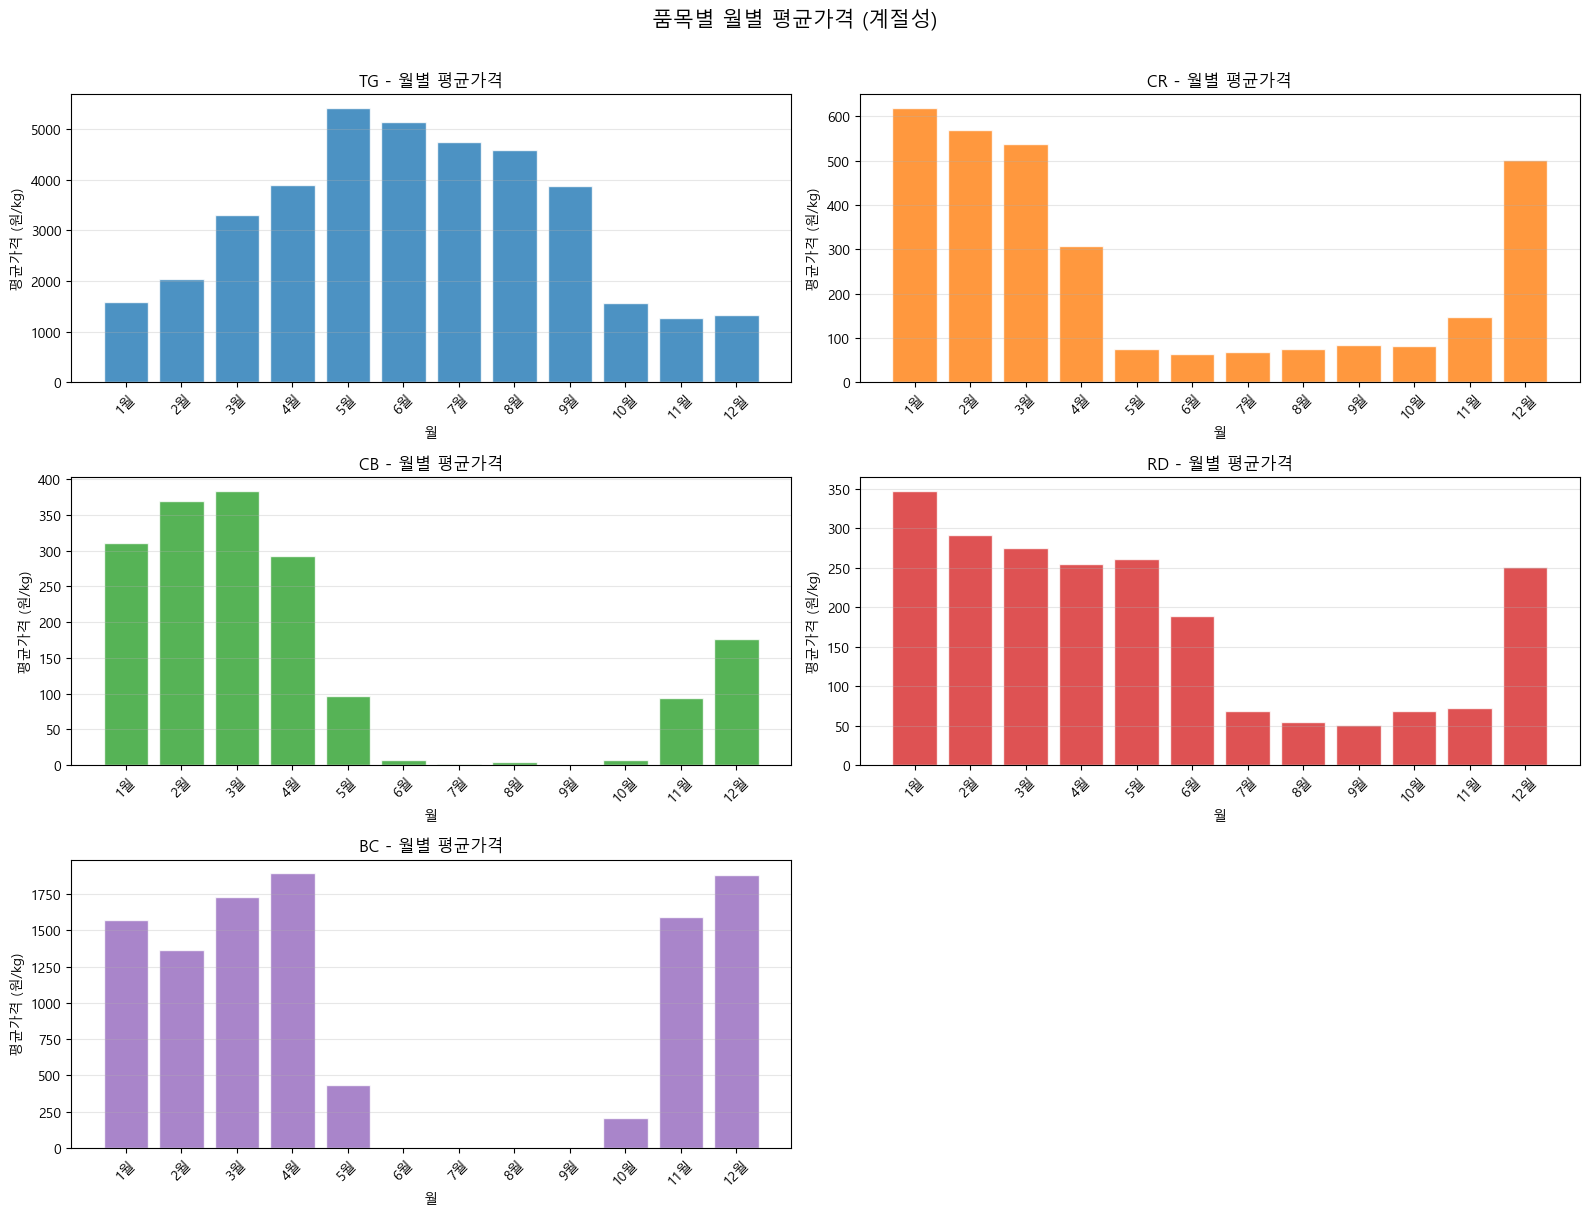

In [61]:
if date_col and target_col and 'month' in train.columns:
    month_labels = ['1월','2월','3월','4월','5월','6월','7월','8월','9월','10월','11월','12월']

    if item_col:
        items = train[item_col].unique()
        n_items = len(items)
        cols = 2
        rows = (n_items + 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        axes = axes.flatten()

        for i, item in enumerate(items):
            df_item = train[train[item_col] == item]
            monthly = df_item.groupby('month')[target_col].mean()
            axes[i].bar(monthly.index, monthly.values, color=f'C{i}', alpha=0.8, edgecolor='white')
            axes[i].set_title(f'{item} - 월별 평균가격', fontsize=12)
            axes[i].set_xlabel('월')
            axes[i].set_ylabel('평균가격 (원/kg)')
            axes[i].set_xticks(range(1, 13))
            axes[i].set_xticklabels([str(m)+'월' for m in range(1, 13)], rotation=45)
            axes[i].grid(True, axis='y', alpha=0.3)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('품목별 월별 평균가격 (계절성)', fontsize=15, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        monthly = train.groupby('month')[target_col].mean()
        plt.figure(figsize=(12, 5))
        plt.bar(monthly.index, monthly.values, color='steelblue', alpha=0.8)
        plt.title('월별 평균가격', fontsize=14)
        plt.xlabel('월')
        plt.ylabel('평균가격 (원/kg)')
        plt.xticks(range(1, 13), [str(m)+'월' for m in range(1, 13)])
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

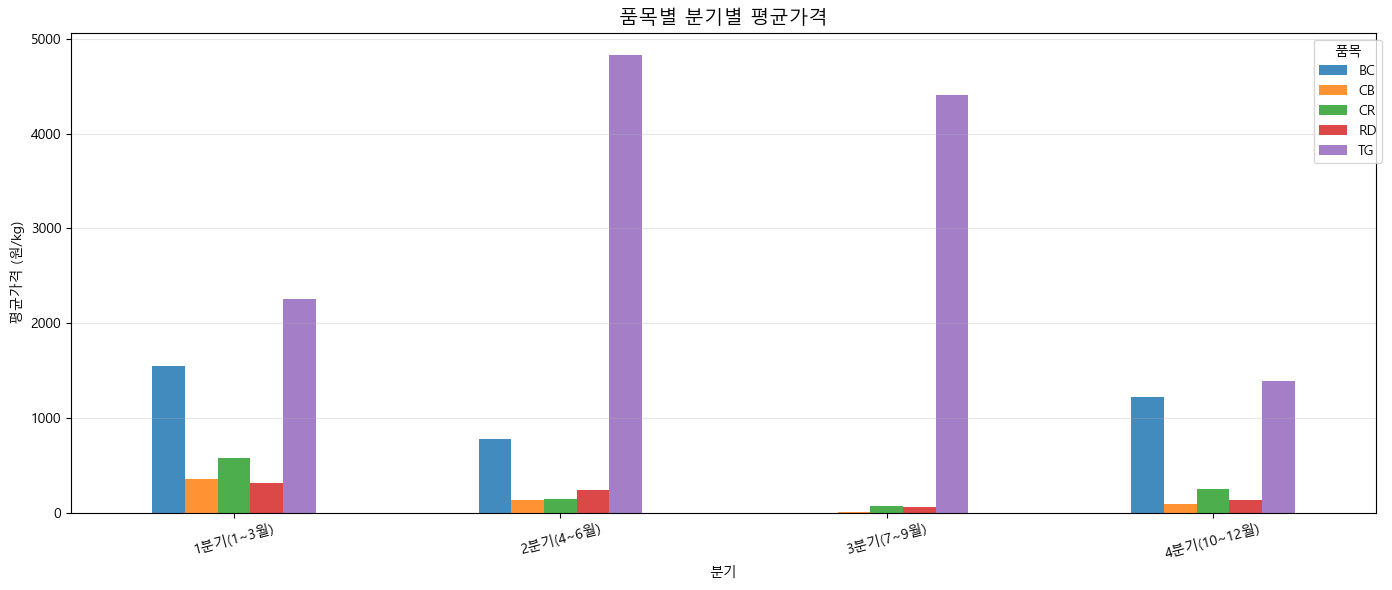

In [62]:
# 분기별 가격 패턴
if date_col and target_col and 'quarter' in train.columns:
    quarter_labels = {1: '1분기(1~3월)', 2: '2분기(4~6월)', 3: '3분기(7~9월)', 4: '4분기(10~12월)'}

    if item_col:
        quarterly = train.groupby([item_col, 'quarter'])[target_col].mean().reset_index()
        pivot_q = quarterly.pivot(index='quarter', columns=item_col, values=target_col)
        pivot_q.index = [quarter_labels[q] for q in pivot_q.index]
        pivot_q.plot(kind='bar', figsize=(14, 6), alpha=0.85)
        plt.title('품목별 분기별 평균가격', fontsize=14)
        plt.xlabel('분기')
        plt.ylabel('평균가격 (원/kg)')
        plt.xticks(rotation=15)
        plt.legend(title='품목', bbox_to_anchor=(1.01, 1))
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

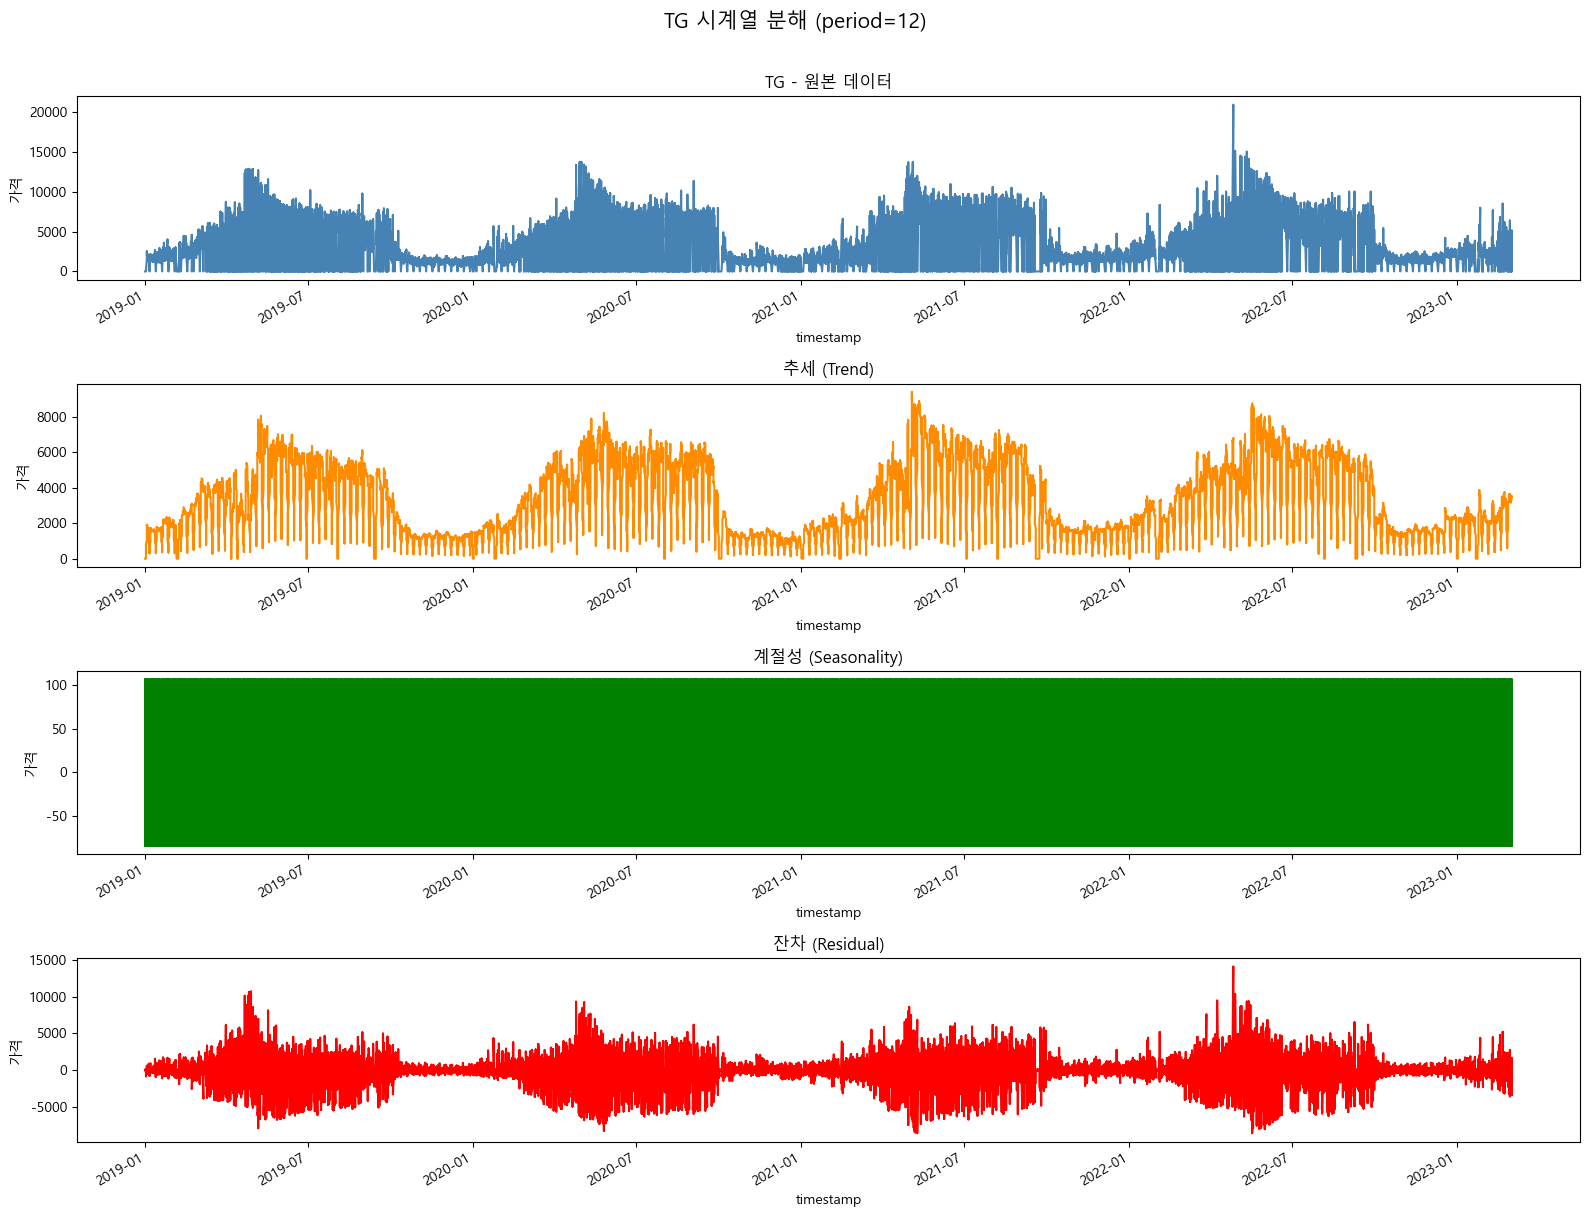

In [63]:
# 시계열 분해 (STL 분해)
if date_col and target_col:
    if item_col:
        # 첫 번째 품목으로 예시
        sample_item = train[item_col].value_counts().index[0]
        df_sample = train[train[item_col] == sample_item].sort_values(date_col).set_index(date_col)
        price_series = df_sample[target_col].dropna()
        item_name = sample_item
    else:
        price_series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        item_name = '전체'

    # 주기 설정 (월별 데이터면 12, 주별이면 52)
    freq = 12  # 월별 데이터 기준

    if len(price_series) > freq * 2:
        try:
            decomp = seasonal_decompose(price_series, model='additive', period=freq)
            fig, axes = plt.subplots(4, 1, figsize=(16, 12))
            decomp.observed.plot(ax=axes[0], color='steelblue')
            axes[0].set_title(f'{item_name} - 원본 데이터', fontsize=12)
            axes[0].set_ylabel('가격')

            decomp.trend.plot(ax=axes[1], color='darkorange')
            axes[1].set_title('추세 (Trend)', fontsize=12)
            axes[1].set_ylabel('가격')

            decomp.seasonal.plot(ax=axes[2], color='green')
            axes[2].set_title('계절성 (Seasonality)', fontsize=12)
            axes[2].set_ylabel('가격')

            decomp.resid.plot(ax=axes[3], color='red')
            axes[3].set_title('잔차 (Residual)', fontsize=12)
            axes[3].set_ylabel('가격')

            plt.suptitle(f'{item_name} 시계열 분해 (period={freq})', fontsize=15, y=1.01)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'시계열 분해 오류: {e}')
            print('데이터 빈도(period) 값을 조정하거나 데이터를 리샘플링하세요.')
    else:
        print(f'데이터 길이({len(price_series)})가 분해에 필요한 최소 길이({freq*2})보다 짧습니다.')

## 8. 상관관계 분석

수치형 컬럼: ['supply(kg)', 'price(원/kg)', 'year', 'month', 'week', 'quarter', 'dayofweek']


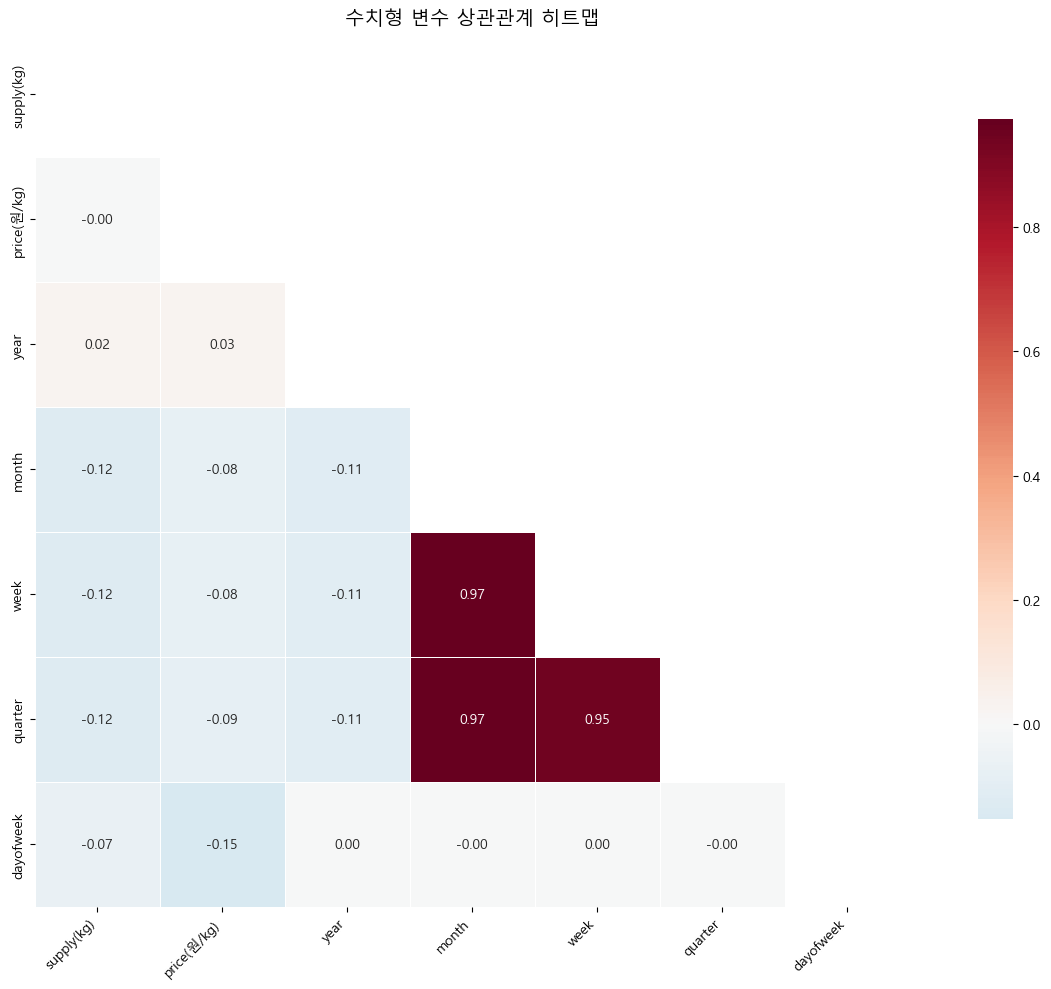

In [64]:
# 수치형 변수 간 상관관계
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
print(f'수치형 컬럼: {numeric_cols}')

if len(numeric_cols) > 1:
    corr_matrix = train[numeric_cols].corr()

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('수치형 변수 상관관계 히트맵', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

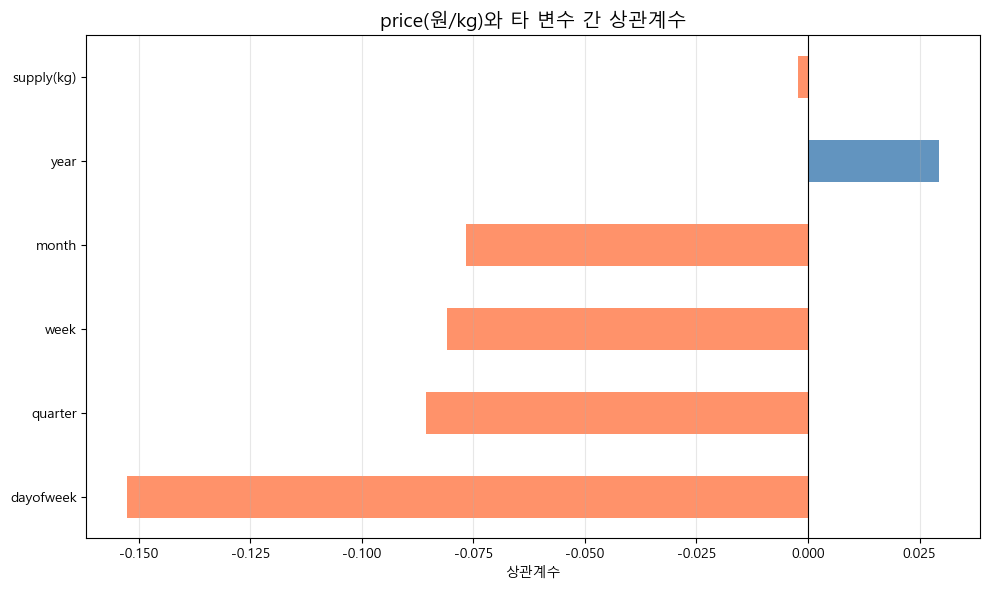

=== 타겟 변수와의 상관관계 TOP 10 ===
dayofweek    -0.152611
quarter      -0.085581
week         -0.080900
month        -0.076673
year          0.029442
supply(kg)   -0.002297
Name: price(원/kg), dtype: float64


In [65]:
# 타겟 변수와의 상관관계 상위 변수
if target_col and len(numeric_cols) > 1:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)

    plt.figure(figsize=(10, 6))
    colors = ['coral' if x < 0 else 'steelblue' for x in target_corr.values]
    target_corr.plot(kind='barh', color=colors, alpha=0.85)
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'{target_col}와 타 변수 간 상관계수', fontsize=14)
    plt.xlabel('상관계수')
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('=== 타겟 변수와의 상관관계 TOP 10 ===')
    print(target_corr.head(10))

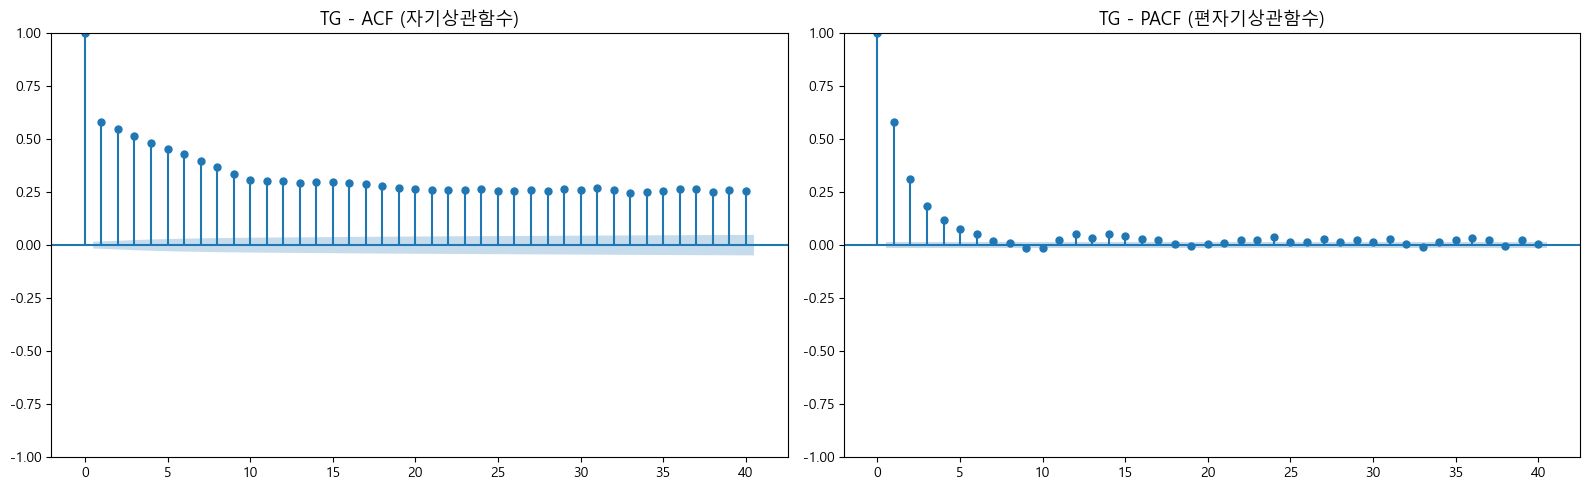

In [66]:
# ACF / PACF 분석
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        price_series = (train[train[item_col] == sample_item]
                        .sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = sample_item
    else:
        price_series = (train.sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = '전체'

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(price_series, lags=40, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'{item_name} - ACF (자기상관함수)', fontsize=13)

    plot_pacf(price_series, lags=40, ax=axes[1], alpha=0.05, method='ywm')
    axes[1].set_title(f'{item_name} - PACF (편자기상관함수)', fontsize=13)

    plt.tight_layout()
    plt.show()

## 9. 이상치 탐지

In [67]:
def detect_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

if target_col:
    if item_col:
        print('=== 품목별 이상치 탐지 (IQR 방법) ===')
        for item in train[item_col].unique():
            series = train[train[item_col] == item][target_col].dropna()
            outliers, lower, upper = detect_outliers_iqr(series)
            pct = len(outliers) / len(series) * 100
            print(f'{item:15s}: 이상치 {len(outliers):4d}개 ({pct:.1f}%)  범위 [{lower:.1f}, {upper:.1f}]')
    else:
        outliers, lower, upper = detect_outliers_iqr(train[target_col].dropna())
        print(f'이상치 수: {len(outliers)} ({len(outliers)/len(train)*100:.1f}%)')
        print(f'정상 범위: [{lower:.1f}, {upper:.1f}]')

=== 품목별 이상치 탐지 (IQR 방법) ===
TG             : 이상치   30개 (0.2%)  범위 [-5818.5, 12343.5]
CR             : 이상치 2082개 (19.5%)  범위 [0.0, 0.0]
CB             : 이상치 1620개 (21.3%)  범위 [0.0, 0.0]
RD             : 이상치  272개 (2.2%)  범위 [-574.5, 957.5]
BC             : 이상치  129개 (0.9%)  범위 [-3048.8, 5081.2]


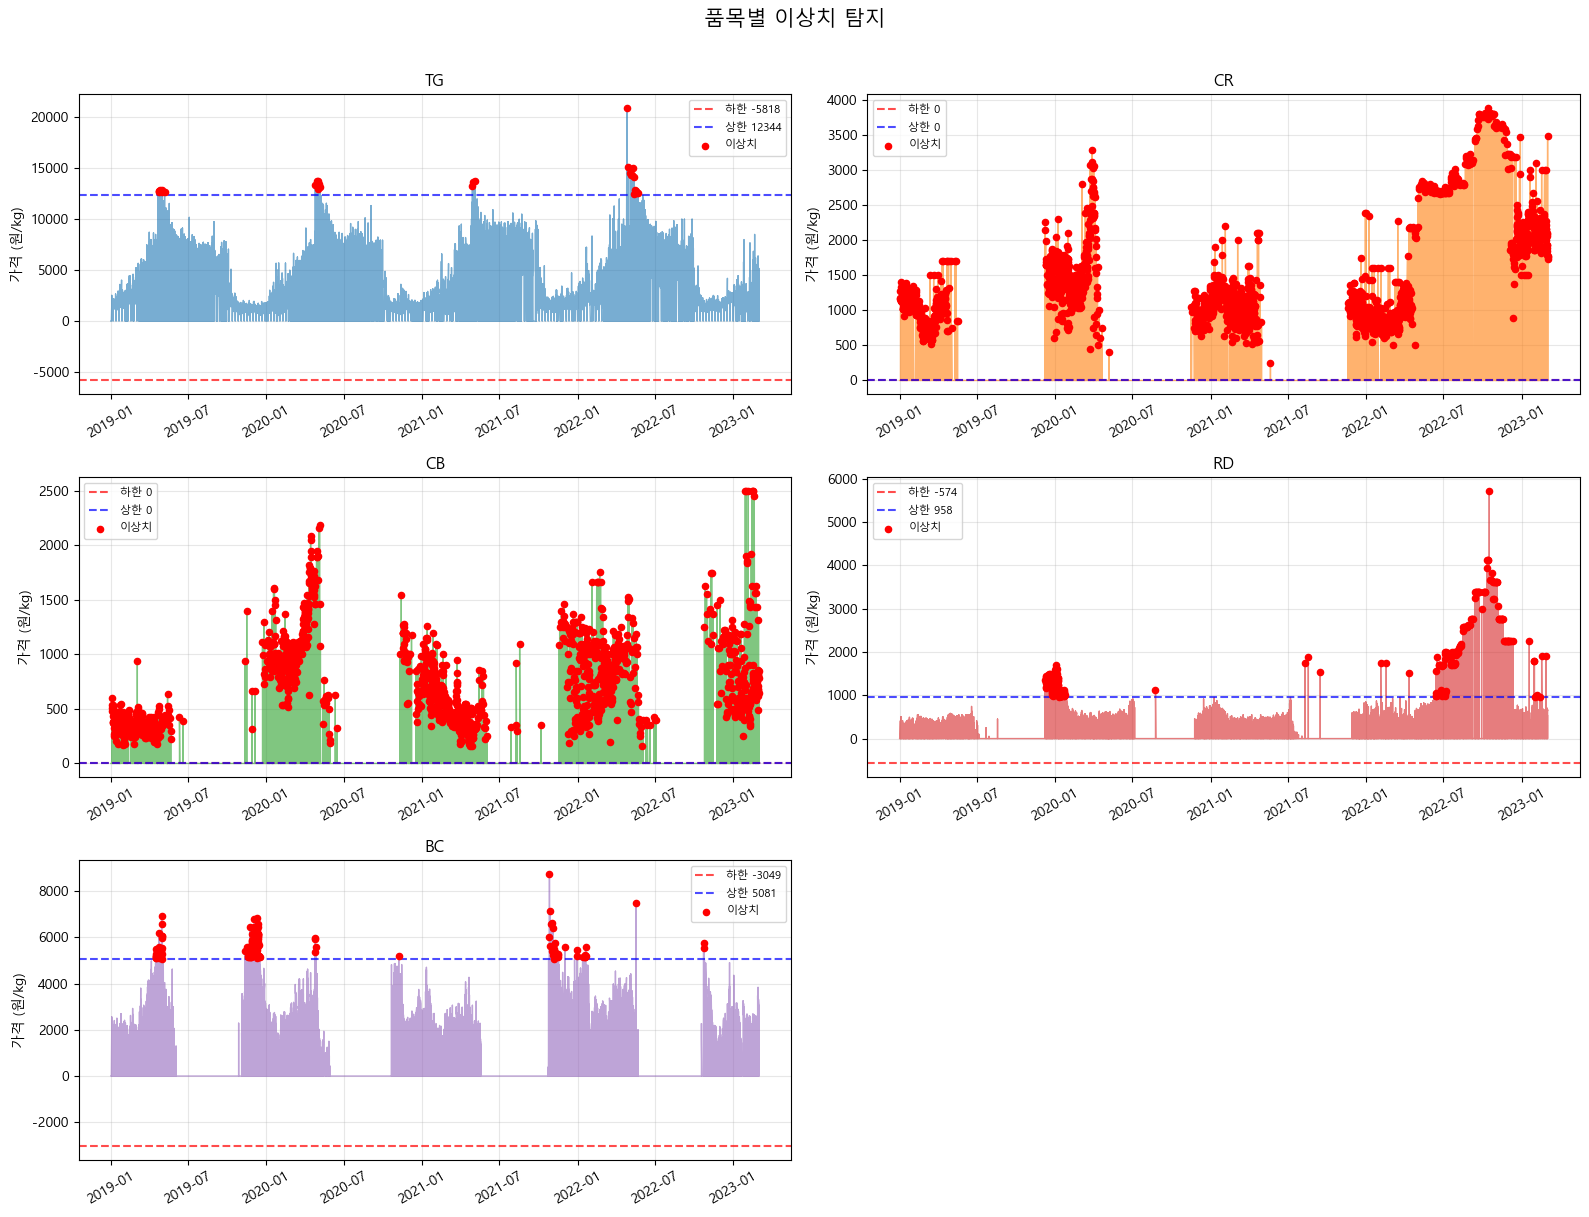

In [68]:
# 이상치 시각화
if date_col and target_col and item_col:
    items = train[item_col].unique()
    n_items = len(items)
    cols = 2
    rows = (n_items + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()

    for i, item in enumerate(items):
        df_item = train[train[item_col] == item].sort_values(date_col)
        series = df_item[target_col]
        outliers_mask, lower, upper = detect_outliers_iqr(series)

        normal_mask = ~series.index.isin(outliers_mask.index)

        axes[i].plot(df_item[date_col], df_item[target_col], color=f'C{i}', alpha=0.6, linewidth=1)
        axes[i].axhline(y=lower, color='red', linestyle='--', alpha=0.7, label=f'하한 {lower:.0f}')
        axes[i].axhline(y=upper, color='blue', linestyle='--', alpha=0.7, label=f'상한 {upper:.0f}')
        
        # 이상치 포인트
        outlier_dates = df_item.loc[df_item[target_col].index.isin(outliers_mask.index), date_col]
        outlier_vals  = df_item.loc[df_item[target_col].index.isin(outliers_mask.index), target_col]
        axes[i].scatter(outlier_dates, outlier_vals, color='red', zorder=5, s=20, label='이상치')

        axes[i].set_title(f'{item}', fontsize=12)
        axes[i].set_ylabel('가격 (원/kg)')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('품목별 이상치 탐지', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

## 10. 정상성 검정

In [69]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'[{name}] ADF 검정')
    print(f'  ADF 통계량   : {result[0]:.4f}')
    print(f'  p-value      : {result[1]:.4f}')
    print(f'  Critical 1%  : {result[4]["1%"]:.4f}')
    print(f'  Critical 5%  : {result[4]["5%"]:.4f}')
    conclusion = '정상(Stationary)' if result[1] < 0.05 else '비정상(Non-Stationary)'
    print(f'  결론         : {conclusion} (p<0.05 기준)\n')
    return result[1] < 0.05

if date_col and target_col:
    print('=== ADF 단위근 검정 (정상성 확인) ===')
    if item_col:
        for item in train[item_col].unique():
            series = (train[train[item_col] == item]
                      .sort_values(date_col)
                      .set_index(date_col)[target_col]
                      .dropna())
            adf_test(series, name=item)
    else:
        series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        adf_test(series, name='전체')

=== ADF 단위근 검정 (정상성 확인) ===
[TG] ADF 검정
  ADF 통계량   : -9.2711
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)

[CR] ADF 검정
  ADF 통계량   : -6.2553
  p-value      : 0.0000
  Critical 1%  : -3.4310
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)

[CB] ADF 검정
  ADF 통계량   : -3.1576
  p-value      : 0.0226
  Critical 1%  : -3.4312
  Critical 5%  : -2.8619
  결론         : 정상(Stationary) (p<0.05 기준)

[RD] ADF 검정
  ADF 통계량   : -8.2453
  p-value      : 0.0000
  Critical 1%  : -3.4309
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)

[BC] ADF 검정
  ADF 통계량   : -5.8188
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8618
  결론         : 정상(Stationary) (p<0.05 기준)



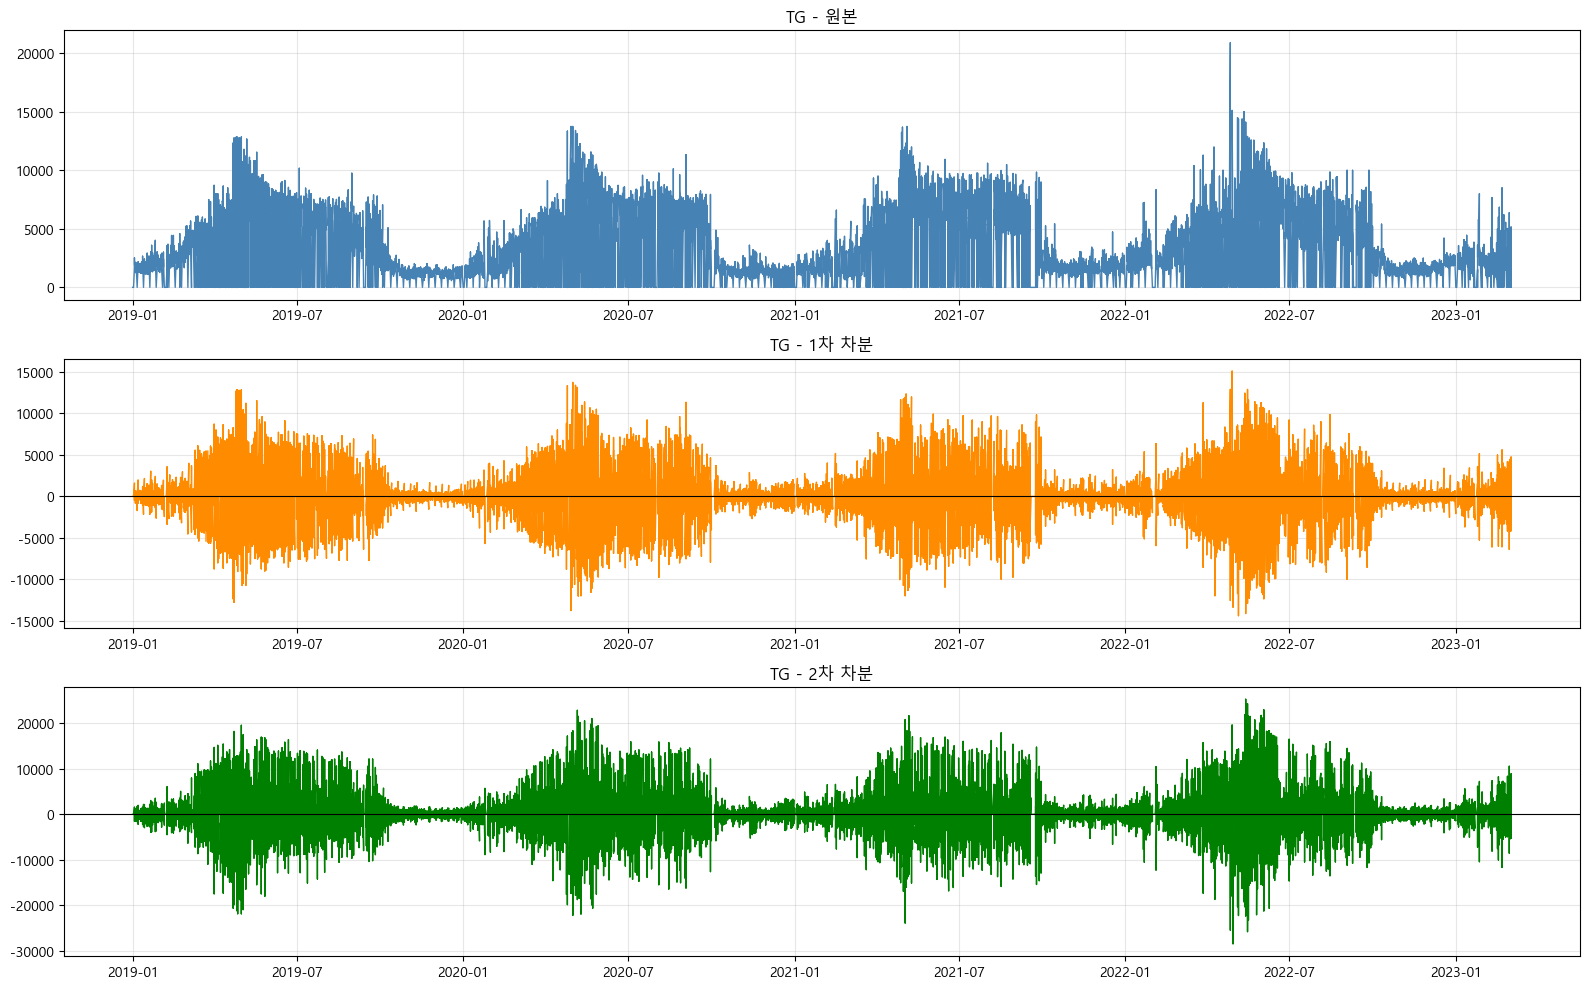

=== 차분 후 정상성 검정 ===
[TG 1차 차분] ADF 검정
  ADF 통계량   : -29.0230
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)

[TG 2차 차분] ADF 검정
  ADF 통계량   : -39.0056
  p-value      : 0.0000
  Critical 1%  : -3.4308
  Critical 5%  : -2.8617
  결론         : 정상(Stationary) (p<0.05 기준)



In [70]:
# 차분 후 정상성 확인
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        price_series = (train[train[item_col] == sample_item]
                        .sort_values(date_col)
                        .set_index(date_col)[target_col]
                        .dropna())
        item_name = sample_item
    else:
        price_series = train.sort_values(date_col).set_index(date_col)[target_col].dropna()
        item_name = '전체'

    diff1 = price_series.diff().dropna()
    diff2 = price_series.diff().diff().dropna()

    fig, axes = plt.subplots(3, 1, figsize=(16, 10))

    axes[0].plot(price_series.index, price_series.values, color='steelblue', linewidth=1)
    axes[0].set_title(f'{item_name} - 원본', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(diff1.index, diff1.values, color='darkorange', linewidth=1)
    axes[1].set_title(f'{item_name} - 1차 차분', fontsize=12)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(diff2.index, diff2.values, color='green', linewidth=1)
    axes[2].set_title(f'{item_name} - 2차 차분', fontsize=12)
    axes[2].axhline(y=0, color='black', linewidth=0.8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('=== 차분 후 정상성 검정 ===')
    adf_test(diff1, name=f'{item_name} 1차 차분')
    adf_test(diff2, name=f'{item_name} 2차 차분')

## 11. 피처 엔지니어링 아이디어 탐색

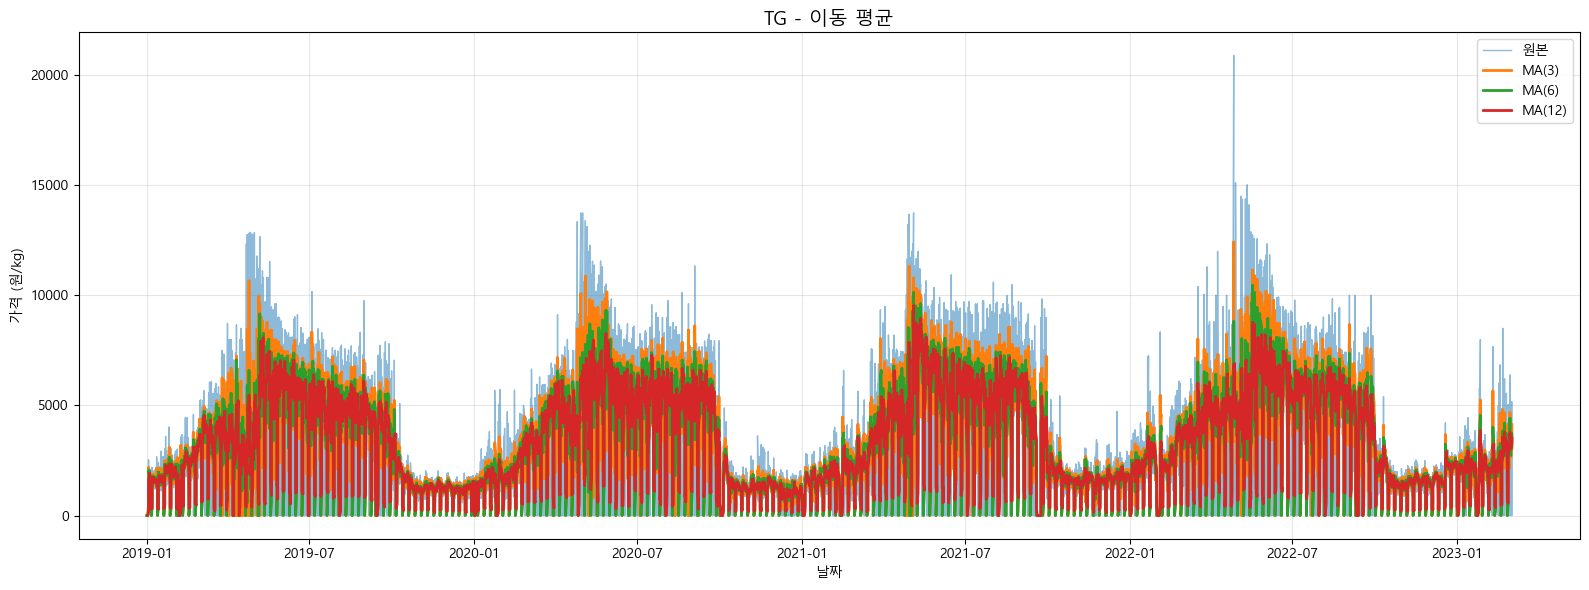

In [71]:
# 이동 평균 및 이동 표준편차
if date_col and target_col:
    if item_col:
        sample_item = train[item_col].value_counts().index[0]
        df_item = train[train[item_col] == sample_item].sort_values(date_col).copy()
        item_name = sample_item
    else:
        df_item = train.sort_values(date_col).copy()
        item_name = '전체'

    windows = [3, 6, 12]

    plt.figure(figsize=(16, 6))
    plt.plot(df_item[date_col], df_item[target_col], label='원본', alpha=0.5, linewidth=1)

    for w in windows:
        ma = df_item[target_col].rolling(w).mean()
        plt.plot(df_item[date_col], ma, label=f'MA({w})', linewidth=2)

    plt.title(f'{item_name} - 이동 평균', fontsize=14)
    plt.xlabel('날짜')
    plt.ylabel('가격 (원/kg)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

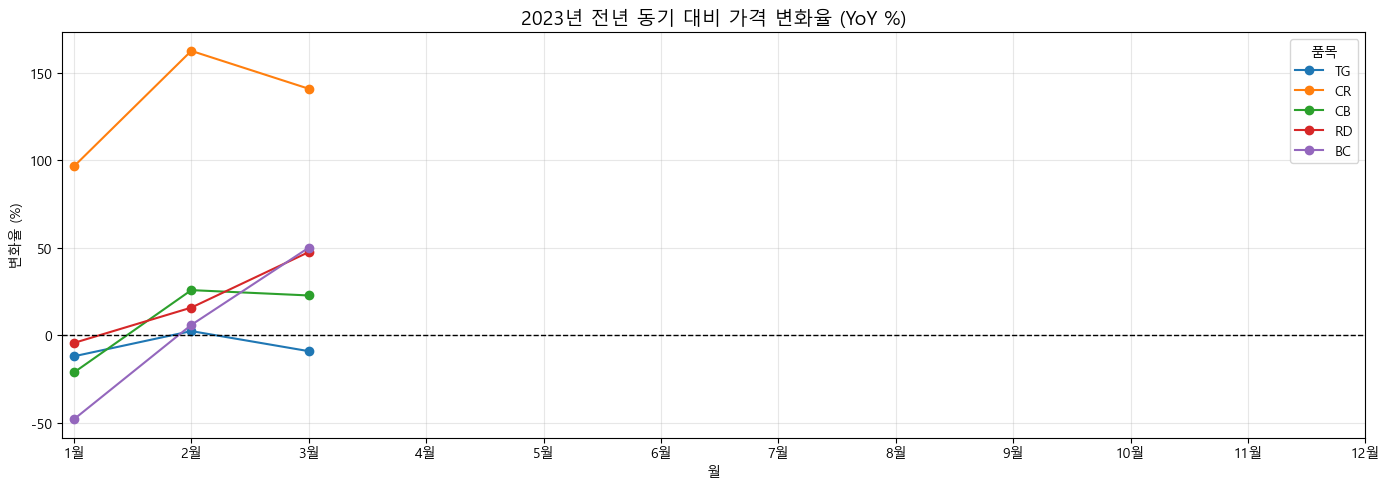

In [72]:
# 전년 동기 대비 가격 변화율 (YoY)
if date_col and target_col and 'year' in train.columns and 'month' in train.columns:
    if item_col:
        yoy_data = []
        for item in train[item_col].unique():
            df_item = train[train[item_col] == item].copy()
            monthly_avg = df_item.groupby(['year', 'month'])[target_col].mean().reset_index()
            monthly_avg = monthly_avg.sort_values(['year', 'month'])
            monthly_avg['yoy_change'] = monthly_avg.groupby('month')[target_col].pct_change() * 100
            monthly_avg[item_col] = item
            yoy_data.append(monthly_avg)

        yoy_df = pd.concat(yoy_data)

        # 최근 연도 YoY
        recent_year = yoy_df['year'].max()
        yoy_recent = yoy_df[yoy_df['year'] == recent_year]

        if len(yoy_recent) > 0 and not yoy_recent['yoy_change'].isna().all():
            plt.figure(figsize=(14, 5))
            for item in yoy_recent[item_col].unique():
                d = yoy_recent[yoy_recent[item_col] == item]
                plt.plot(d['month'], d['yoy_change'], marker='o', label=item)

            plt.axhline(y=0, color='black', linewidth=1, linestyle='--')
            plt.title(f'{recent_year}년 전년 동기 대비 가격 변화율 (YoY %)', fontsize=14)
            plt.xlabel('월')
            plt.ylabel('변화율 (%)')
            plt.xticks(range(1, 13), [str(m)+'월' for m in range(1, 13)])
            plt.legend(title='품목')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

## 12. EDA 인사이트 요약

In [73]:
print('=' * 60)
print('         EDA 인사이트 요약')
print('=' * 60)
print()
print('[데이터 구조]')
print(f'  - Train: {train.shape[0]:,}행 x {train.shape[1]}열')
print(f'  - Test : {test.shape[0]:,}행 x {test.shape[1]}열')
if date_col:
    print(f'  - 학습 기간: {train[date_col].min().date()} ~ {train[date_col].max().date()}')
if item_col:
    print(f'  - 예측 품목: {list(train[item_col].unique())}')
print()

print('[결측치]')
null_summary = train.isnull().sum()
if null_summary.sum() == 0:
    print('  - 결측치 없음')
else:
    for col, cnt in null_summary[null_summary > 0].items():
        print(f'  - {col}: {cnt}개 ({cnt/len(train)*100:.1f}%)')
print()

print('[타겟 변수]')
if target_col:
    print(f'  - 컬럼: {target_col}')
    print(f'  - 평균: {train[target_col].mean():.1f} 원/kg')
    print(f'  - 표준편차: {train[target_col].std():.1f} 원/kg')
    print(f'  - 왜도: {train[target_col].skew():.3f} (1 이상이면 로그 변환 권장)')
print()

print('[권장 모델링 방향]')
print('  1. 시계열 특성 피처 엔지니어링 (lag, rolling_mean, rolling_std)')
print('  2. 계절성 인코딩 (month, quarter, week sin/cos 변환)')
print('  3. 품목별 개별 모델 vs 통합 모델 비교')
print('  4. 추천 모델: LightGBM, XGBoost, Prophet, LSTM, N-BEATS')
print('  5. 타겟 로그 변환 여부 확인 후 결정')
print('=' * 60)

         EDA 인사이트 요약

[데이터 구조]
  - Train: 59,397행 x 12열
  - Test : 1,092행 x 5열
  - 학습 기간: 2019-01-01 ~ 2023-03-03
  - 예측 품목: ['TG', 'CR', 'CB', 'RD', 'BC']

[결측치]
  - 결측치 없음

[타겟 변수]
  - 컬럼: price(원/kg)
  - 평균: 1131.7 원/kg
  - 표준편차: 2029.9 원/kg
  - 왜도: 2.185 (1 이상이면 로그 변환 권장)

[권장 모델링 방향]
  1. 시계열 특성 피처 엔지니어링 (lag, rolling_mean, rolling_std)
  2. 계절성 인코딩 (month, quarter, week sin/cos 변환)
  3. 품목별 개별 모델 vs 통합 모델 비교
  4. 추천 모델: LightGBM, XGBoost, Prophet, LSTM, N-BEATS
  5. 타겟 로그 변환 여부 확인 후 결정
